The goal here is to find one non-repeting pattern in an image. First, find the pattern, then second, compute correlation.


<!-- TEASER_END -->

Let's first initialize the notebook:

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
import numpy as np
phi = (np.sqrt(5)+1)/2
fig_width = 15
figsize = (fig_width, fig_width/phi)

In [2]:
im = plt.imread('../files/2021-12-01-99999999999998.jpg')
im = im.sum(axis=-1)

In [3]:
N_X, N_Y = im.shape
N_X, N_Y

(900, 1220)

Original image

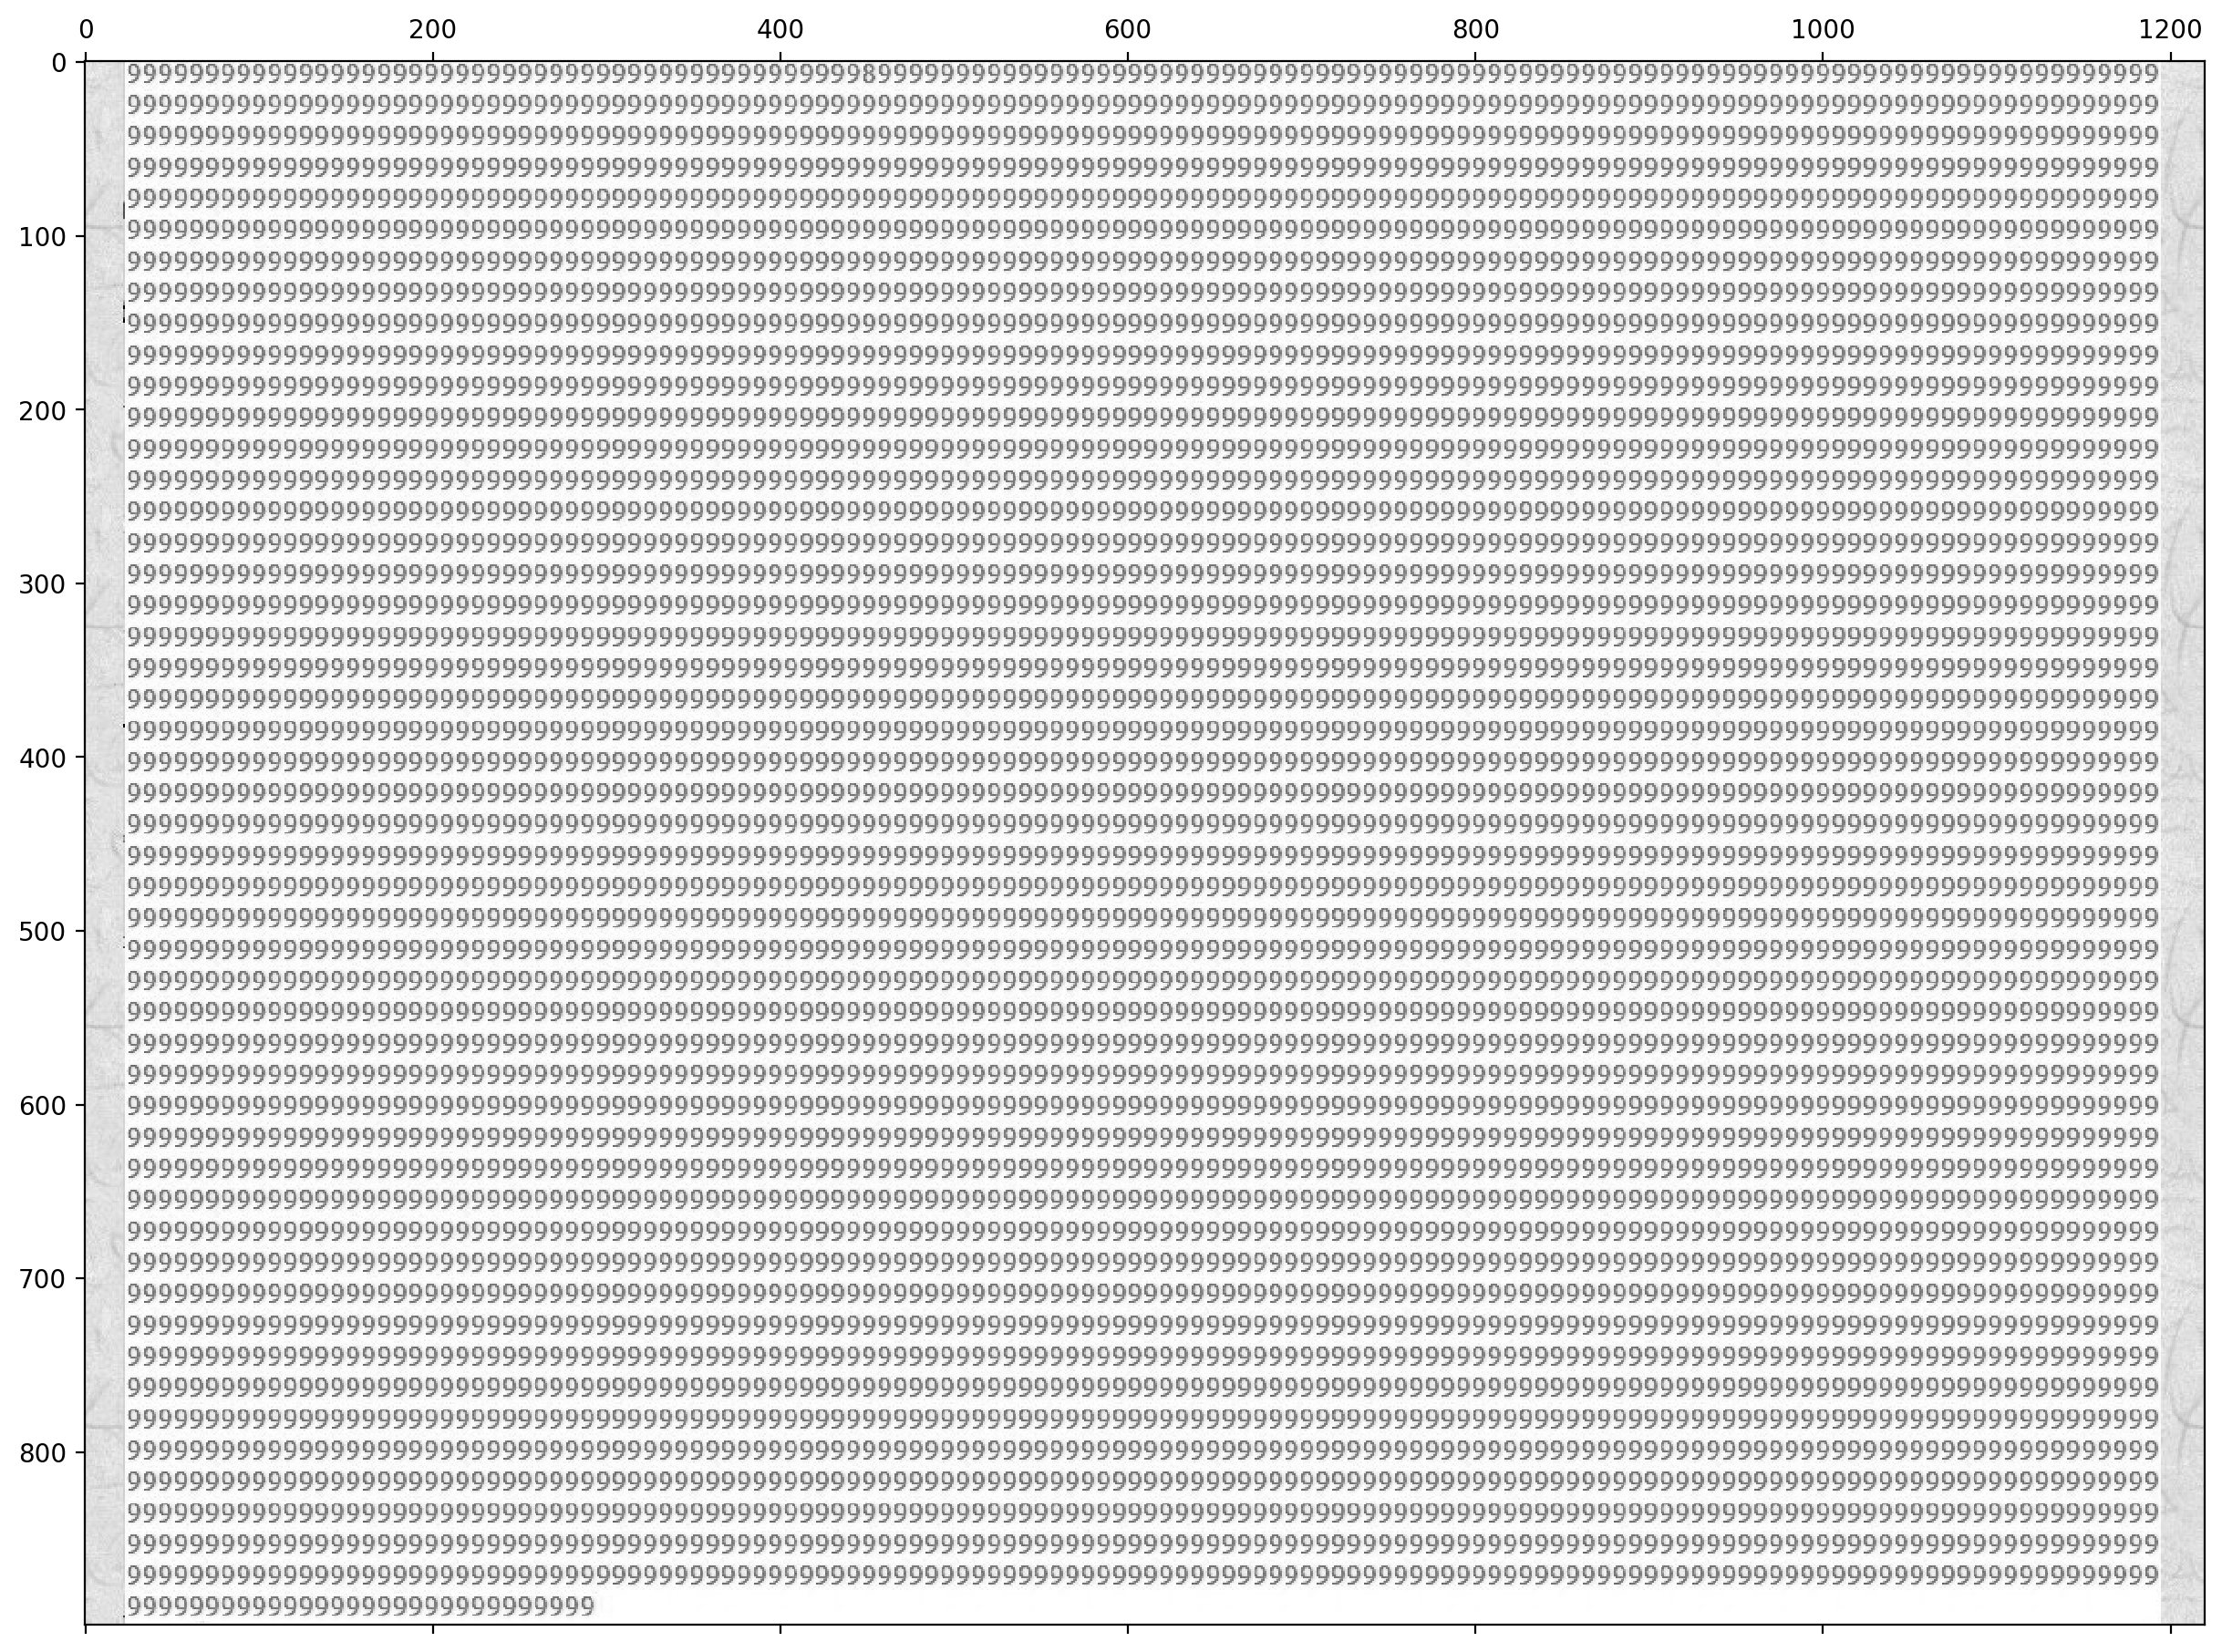

In [4]:
fig, ax = plt.subplots(figsize=(fig_width, fig_width))
ax.matshow(im, cmap=plt.gray());

Zoom

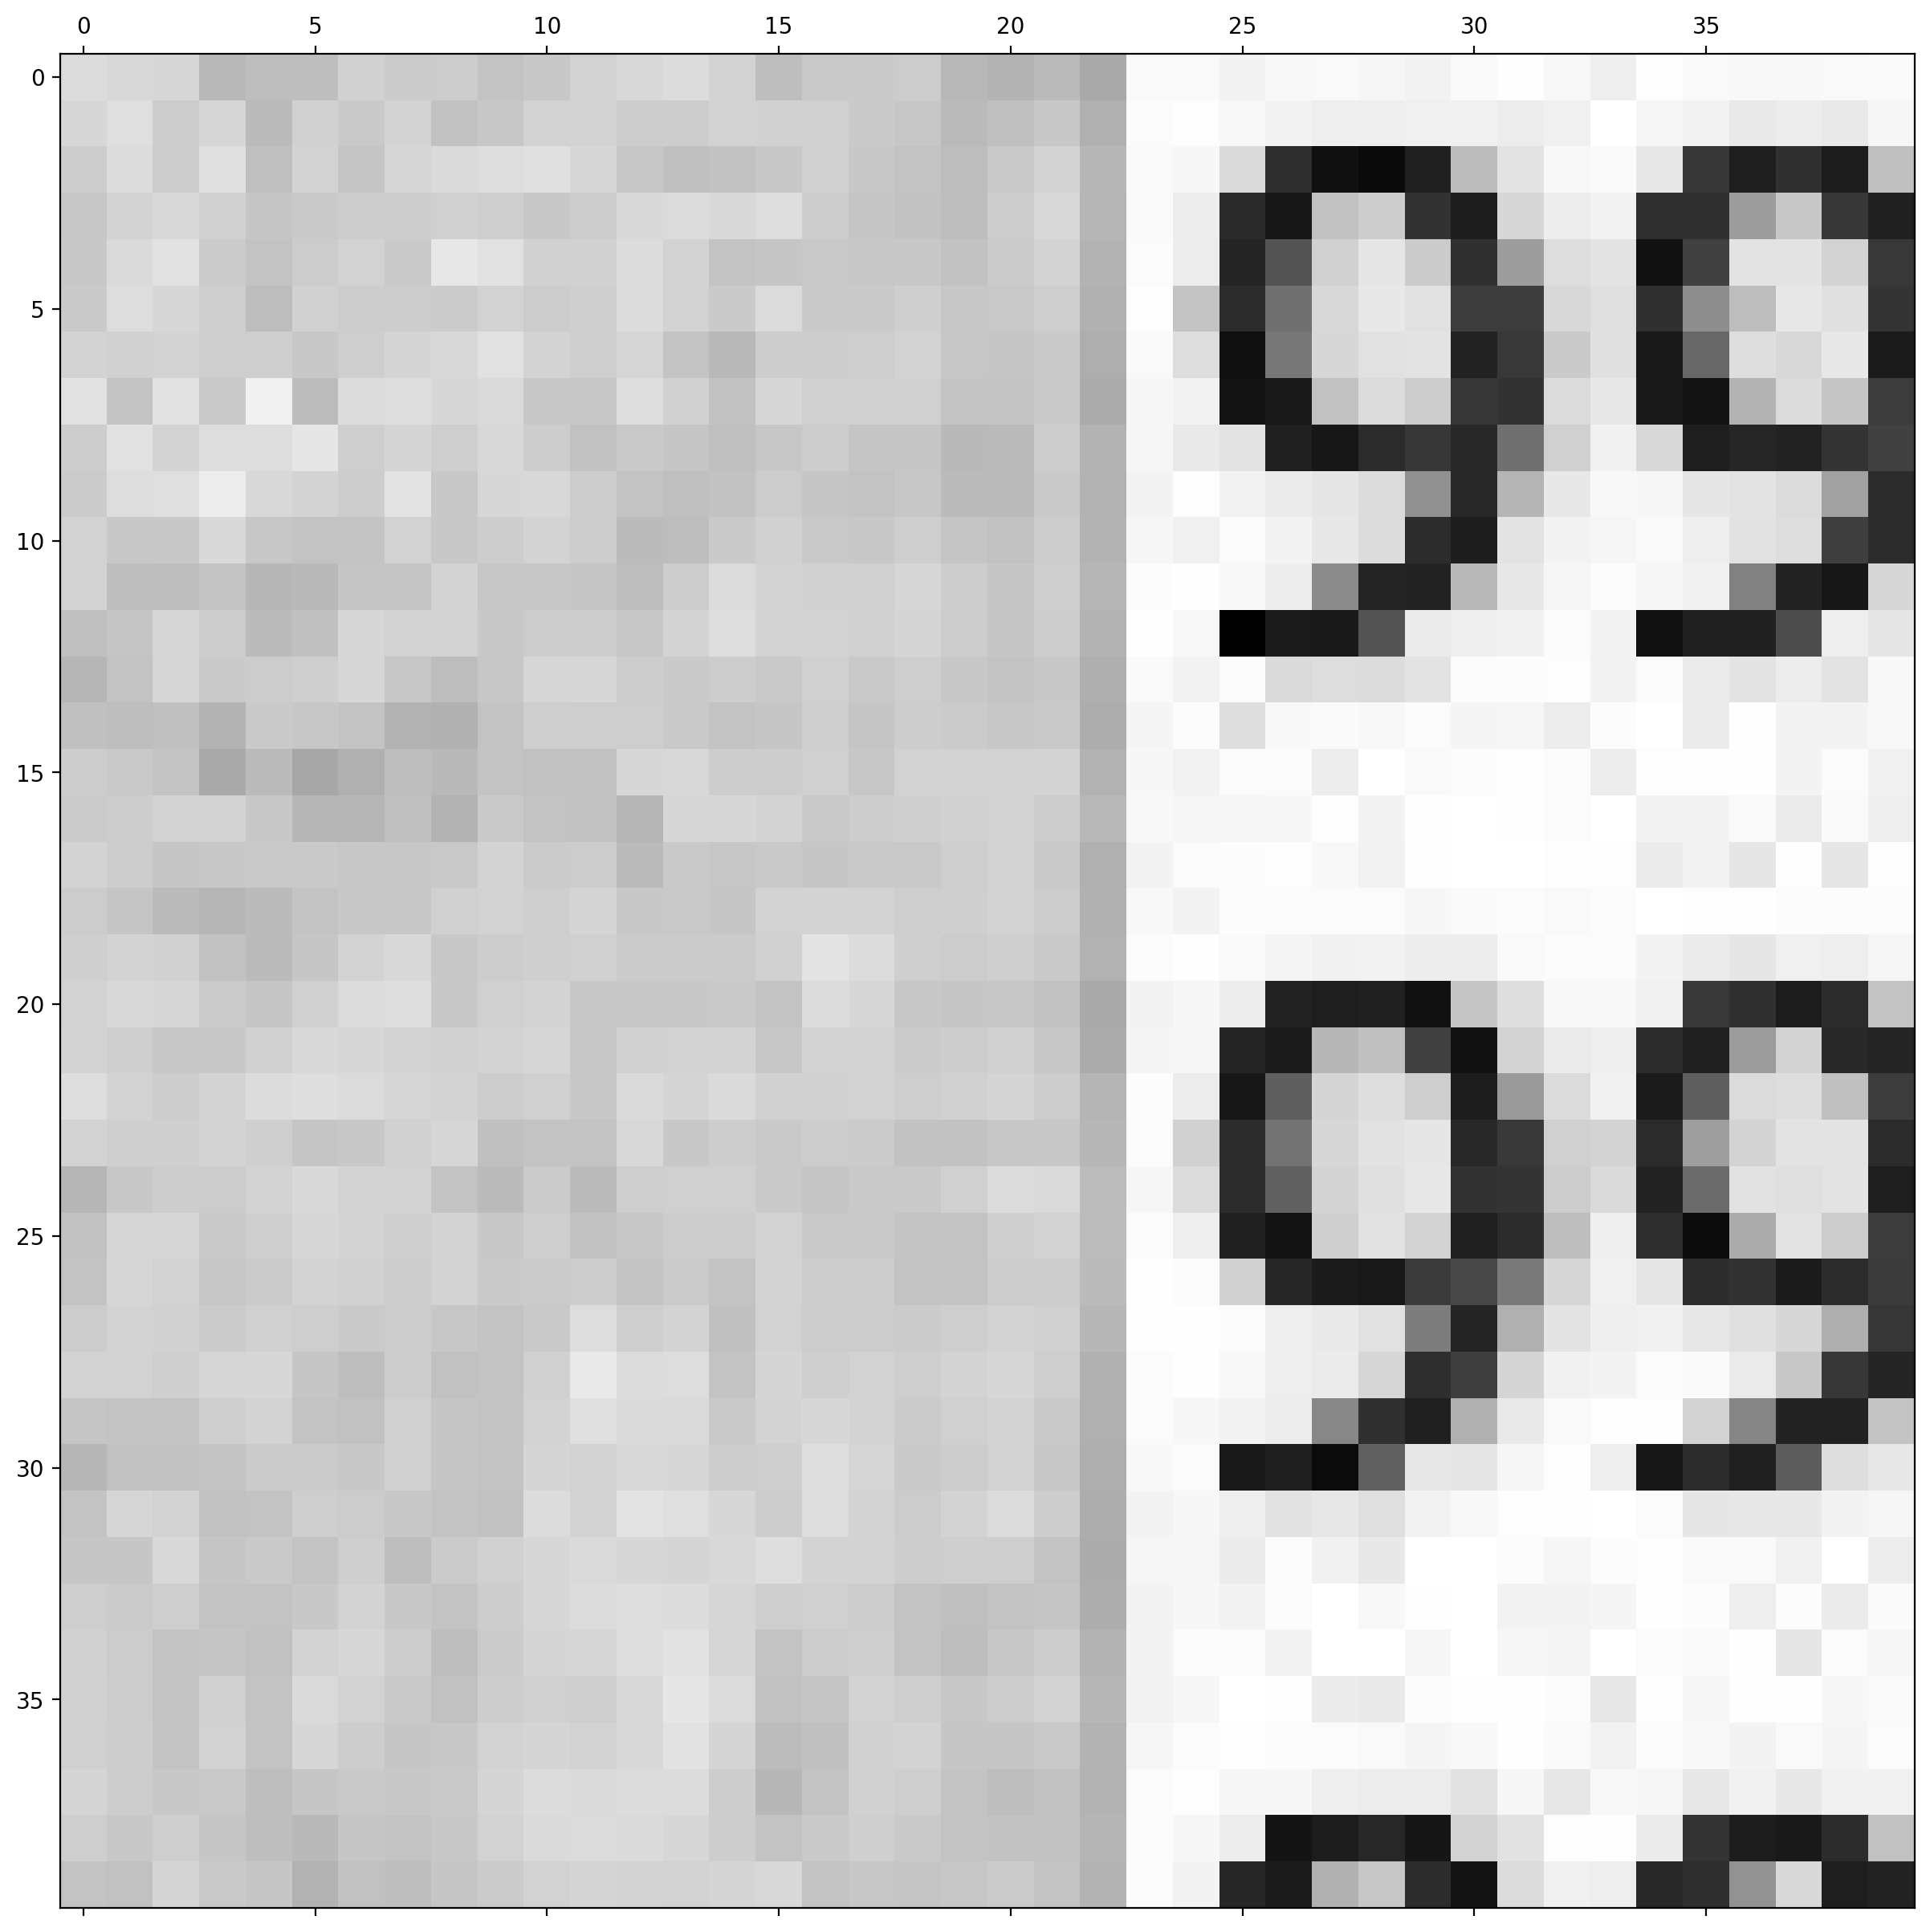

In [5]:
fig, ax = plt.subplots(figsize=(fig_width, fig_width))
ax.matshow(im[:40, :40]);

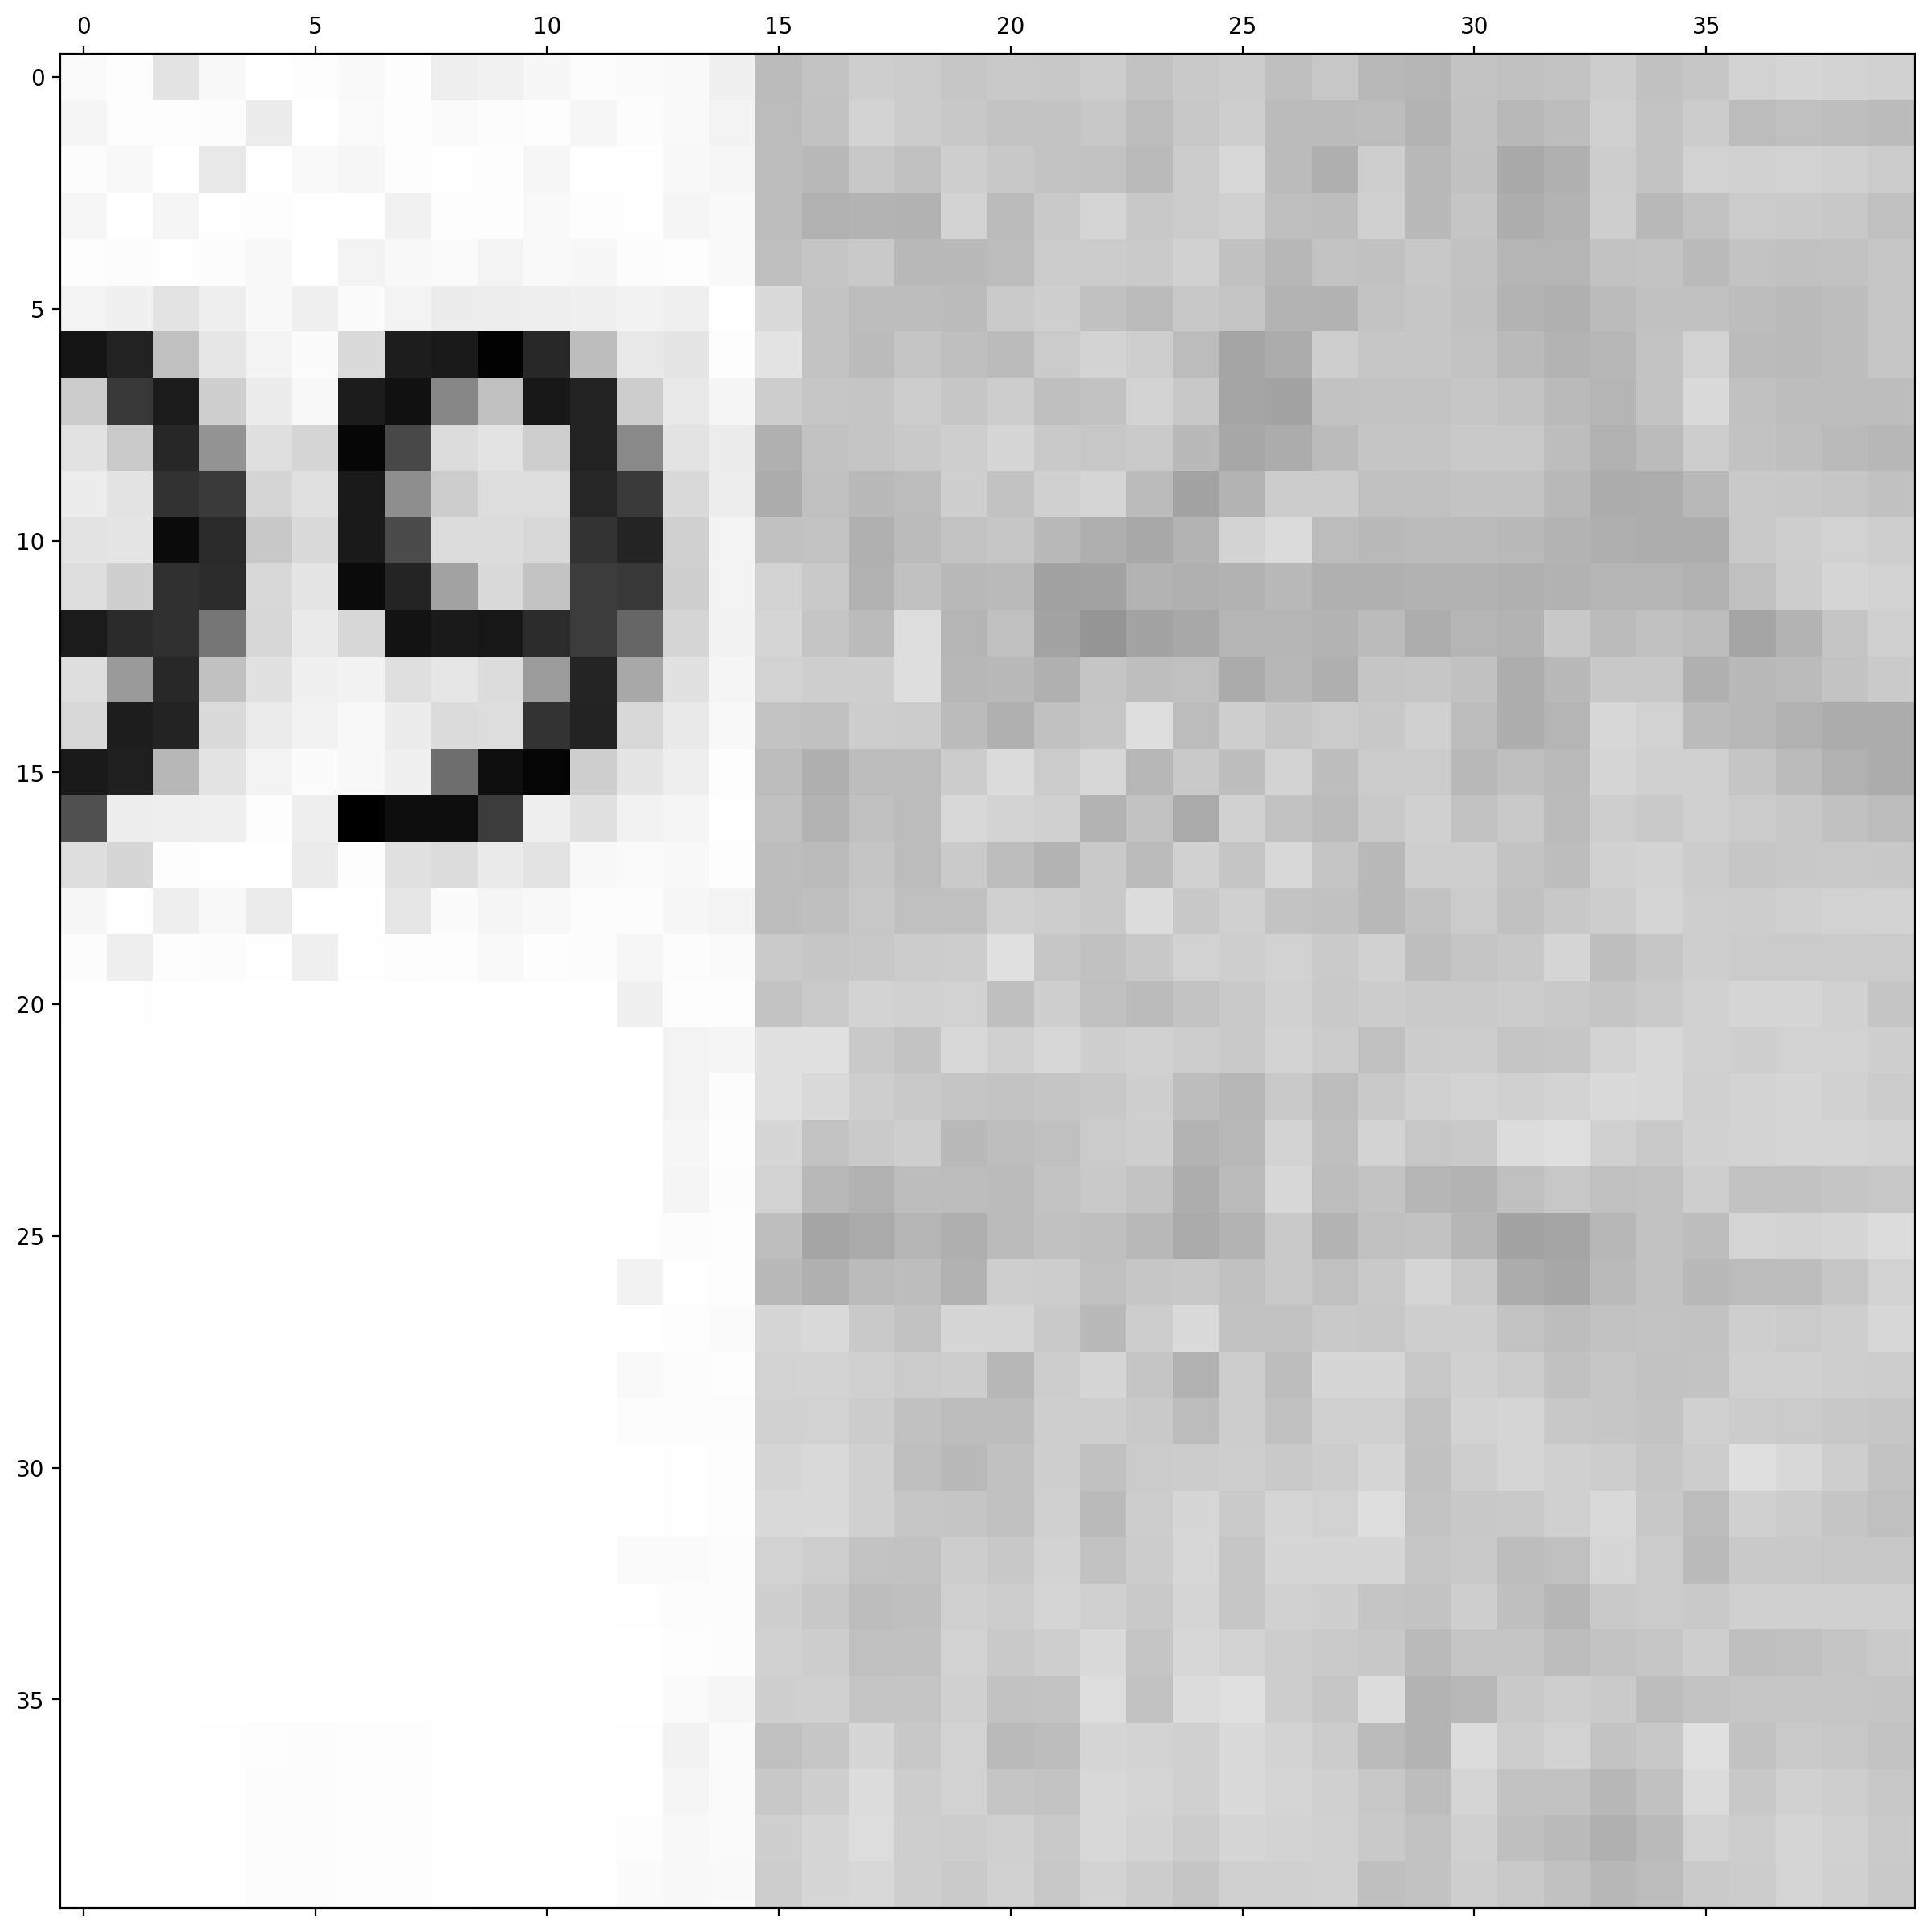

In [6]:
fig, ax = plt.subplots(figsize=(fig_width, fig_width))
ax.matshow(im[-40:, -40:]);

Crop

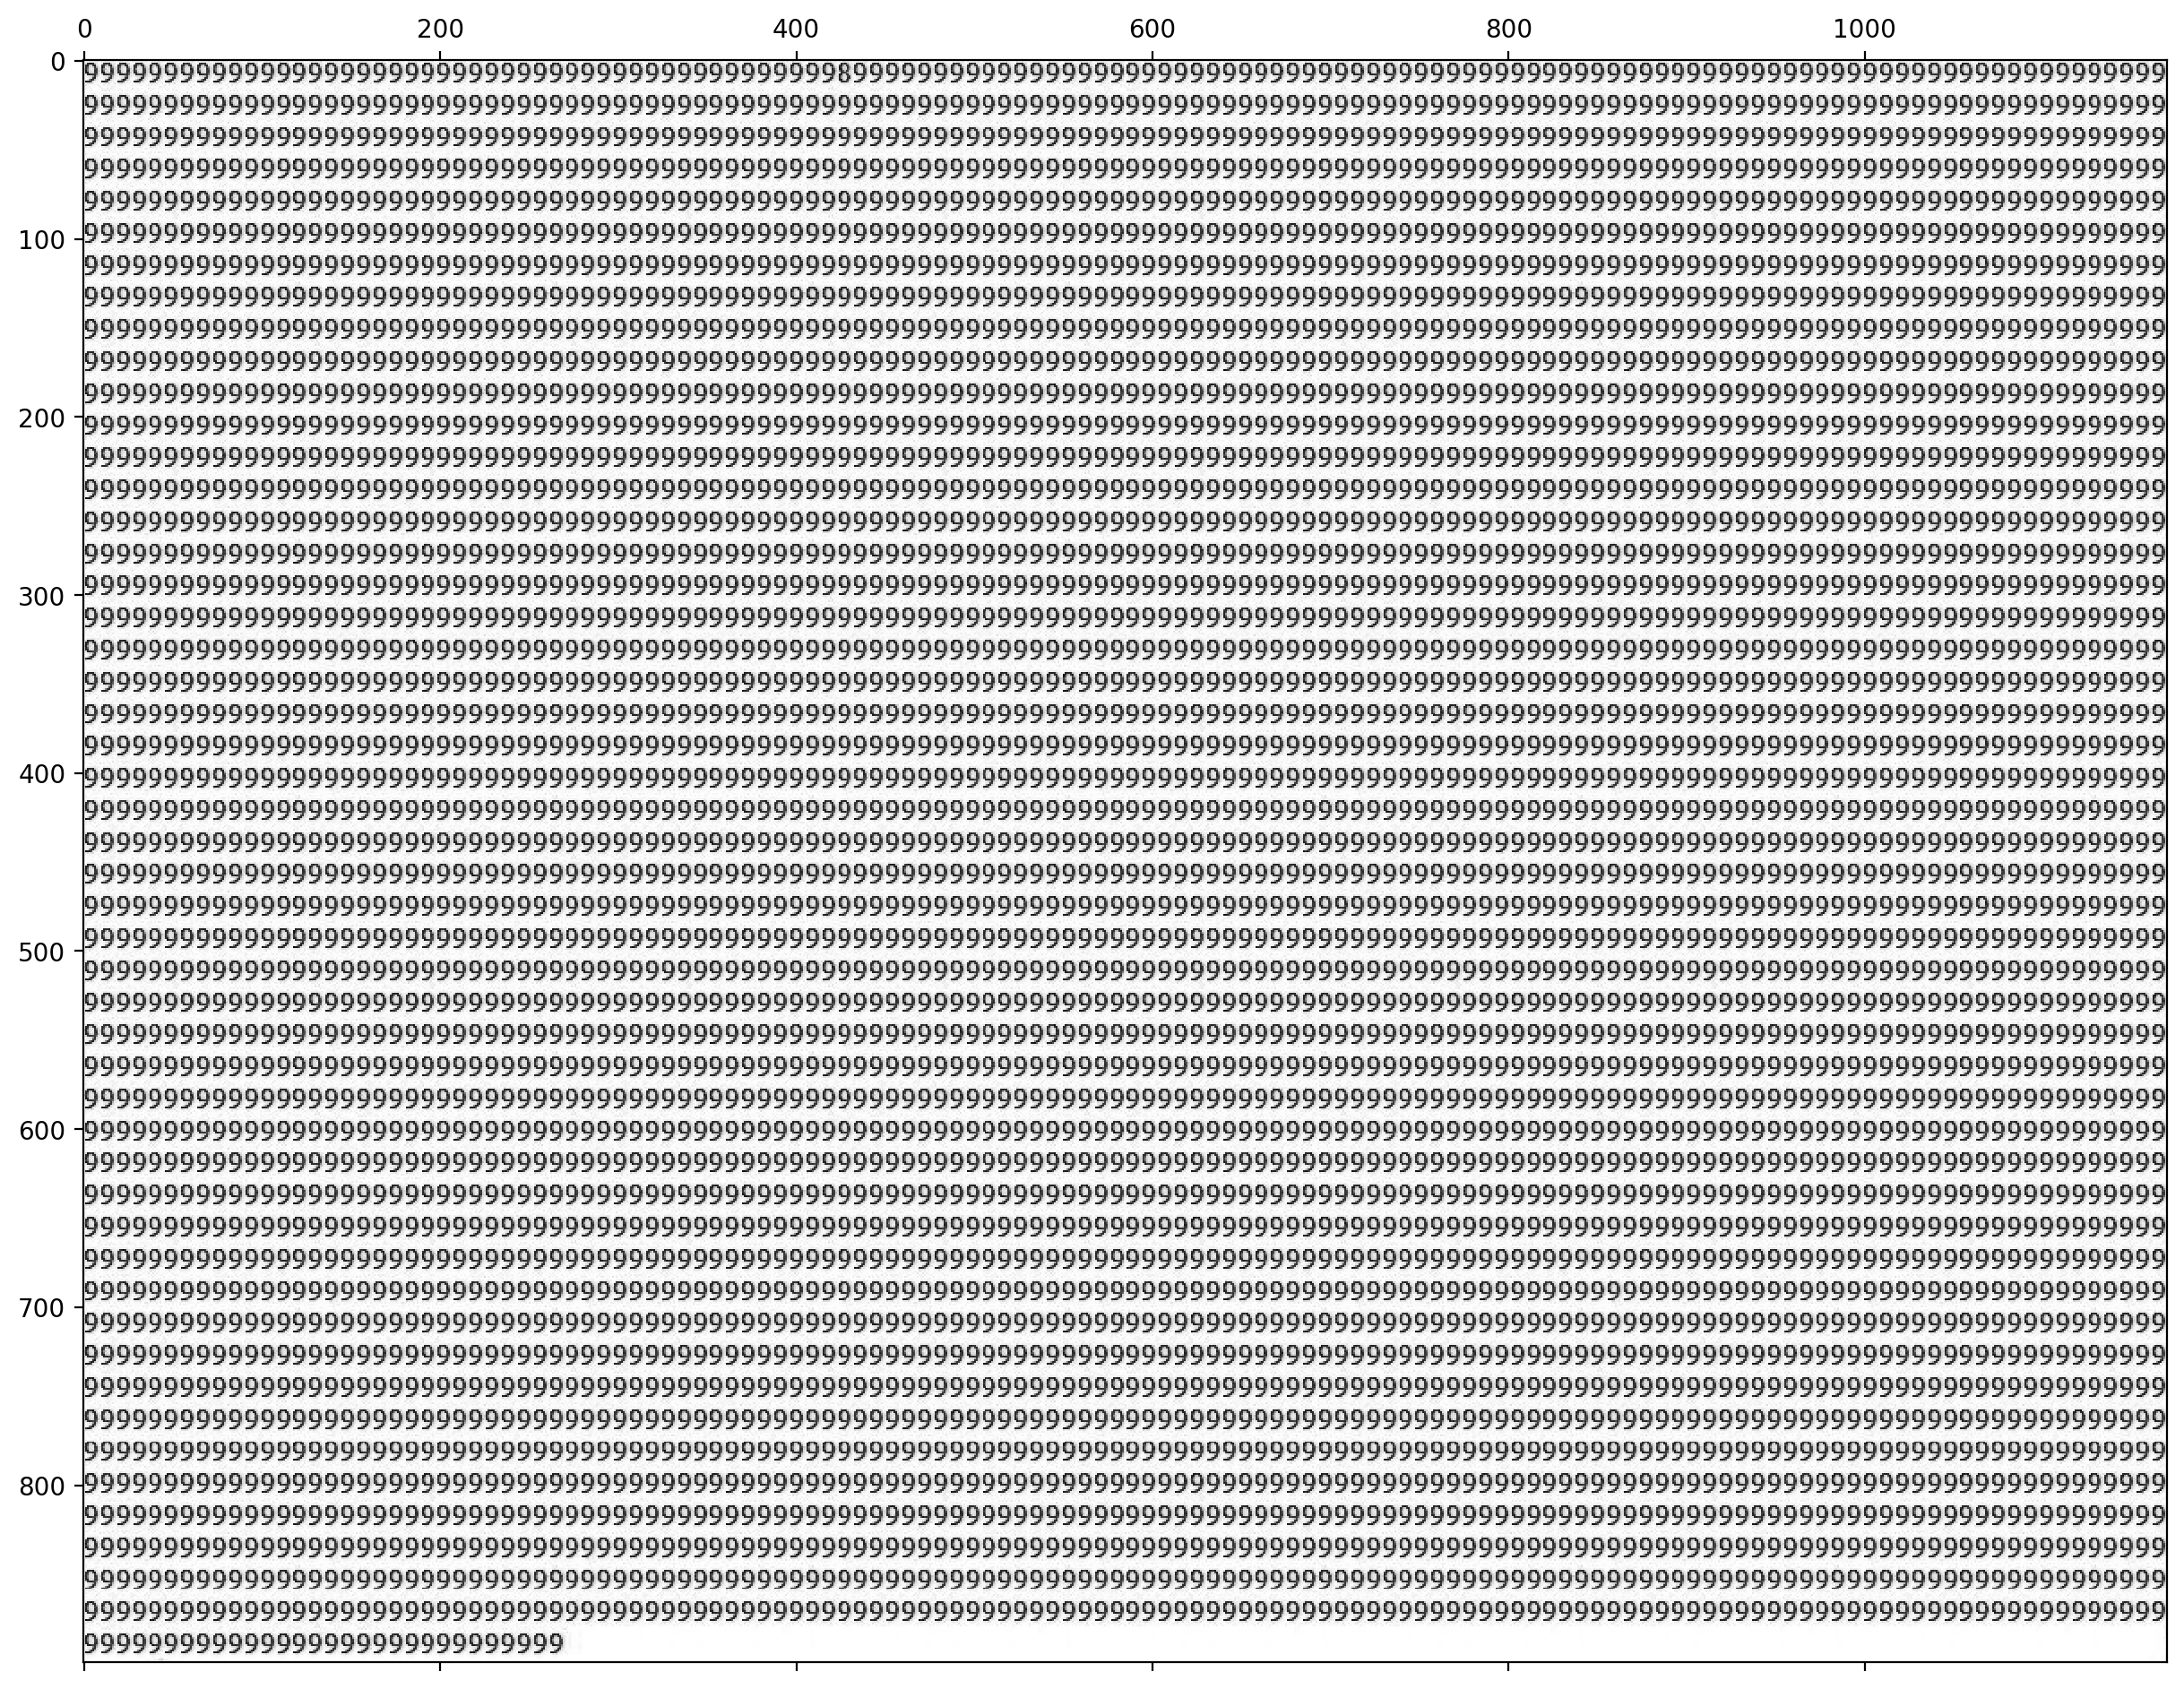

In [7]:
im = im[:, 24:1194]
fig, ax = plt.subplots(figsize=(fig_width, fig_width))
ax.matshow(im, cmap=plt.gray());

Let's smooth a bit the image to reduce noise

In [8]:
from scipy import ndimage

# Define a simple edge detection kernel 
kernel = np.array([[0, 1, 0],
                   [1, 4, 1],
                   [0, 1, 0]])/8.

# Perform the convolution
im = ndimage.convolve(im*1., kernel, mode='reflect')

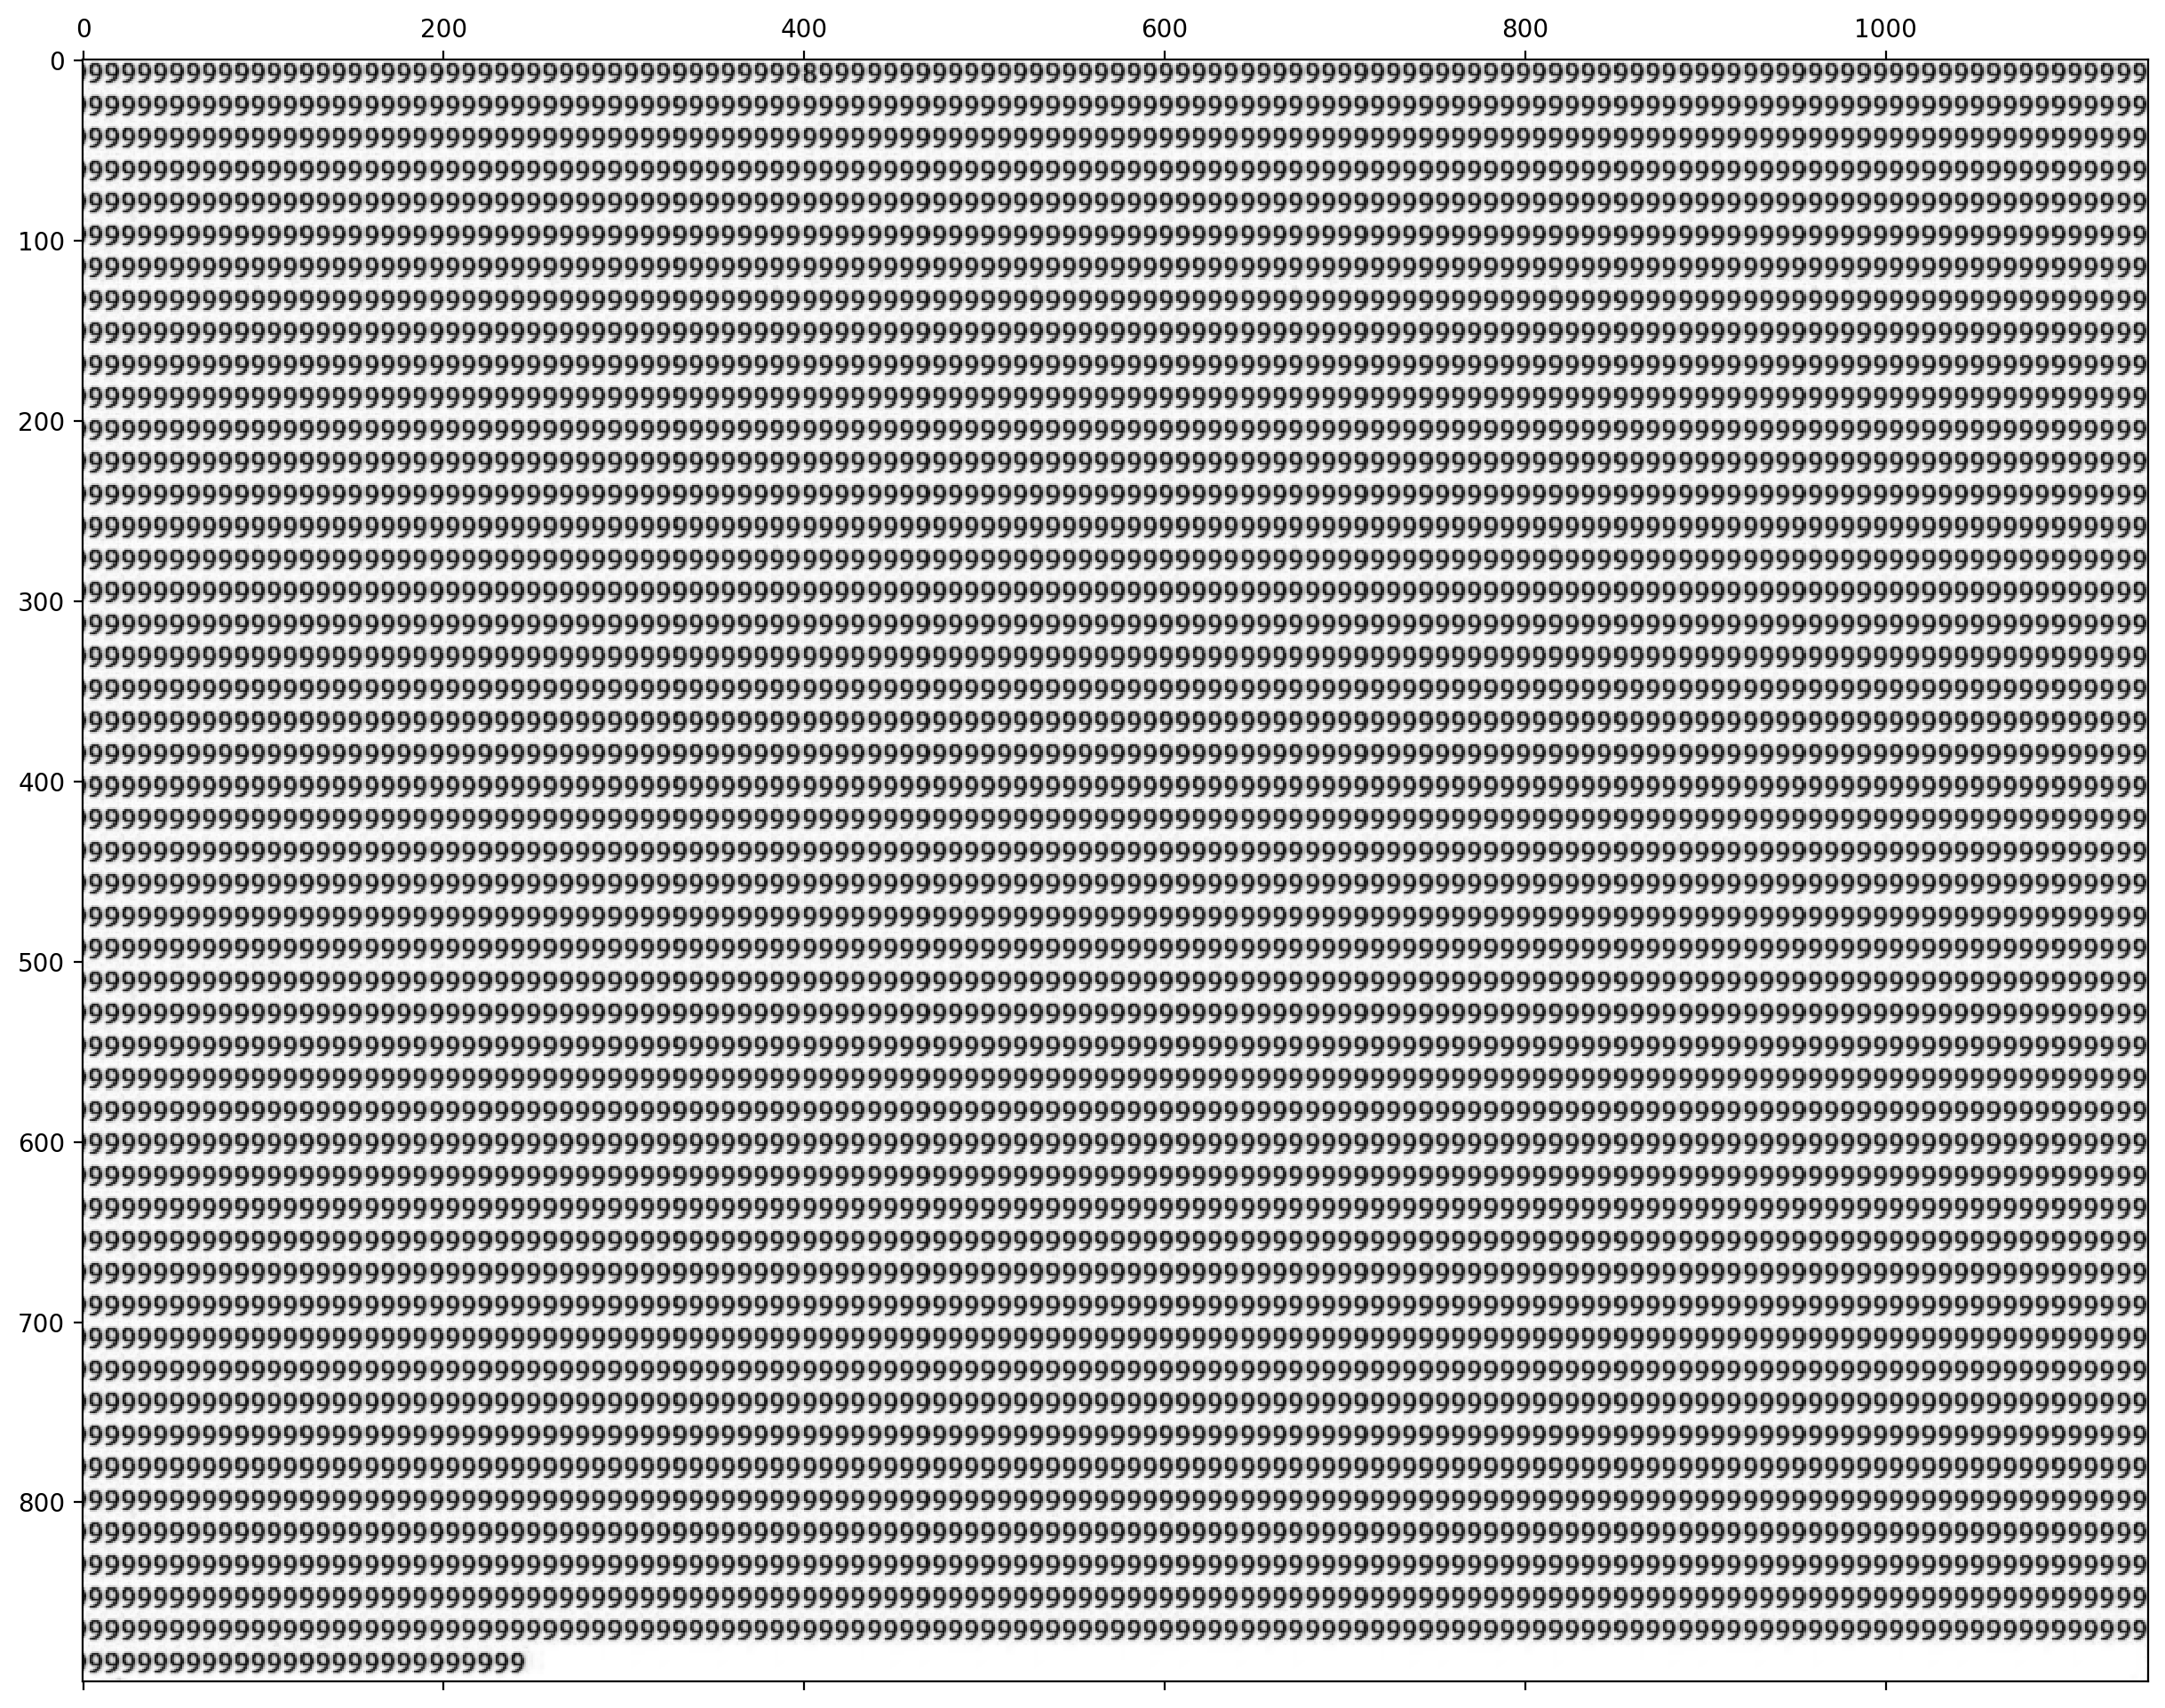

In [9]:
im = im[:, 24:1194]
fig, ax = plt.subplots(figsize=(fig_width, fig_width))
ax.matshow(im, cmap=plt.gray());

Average on one axis

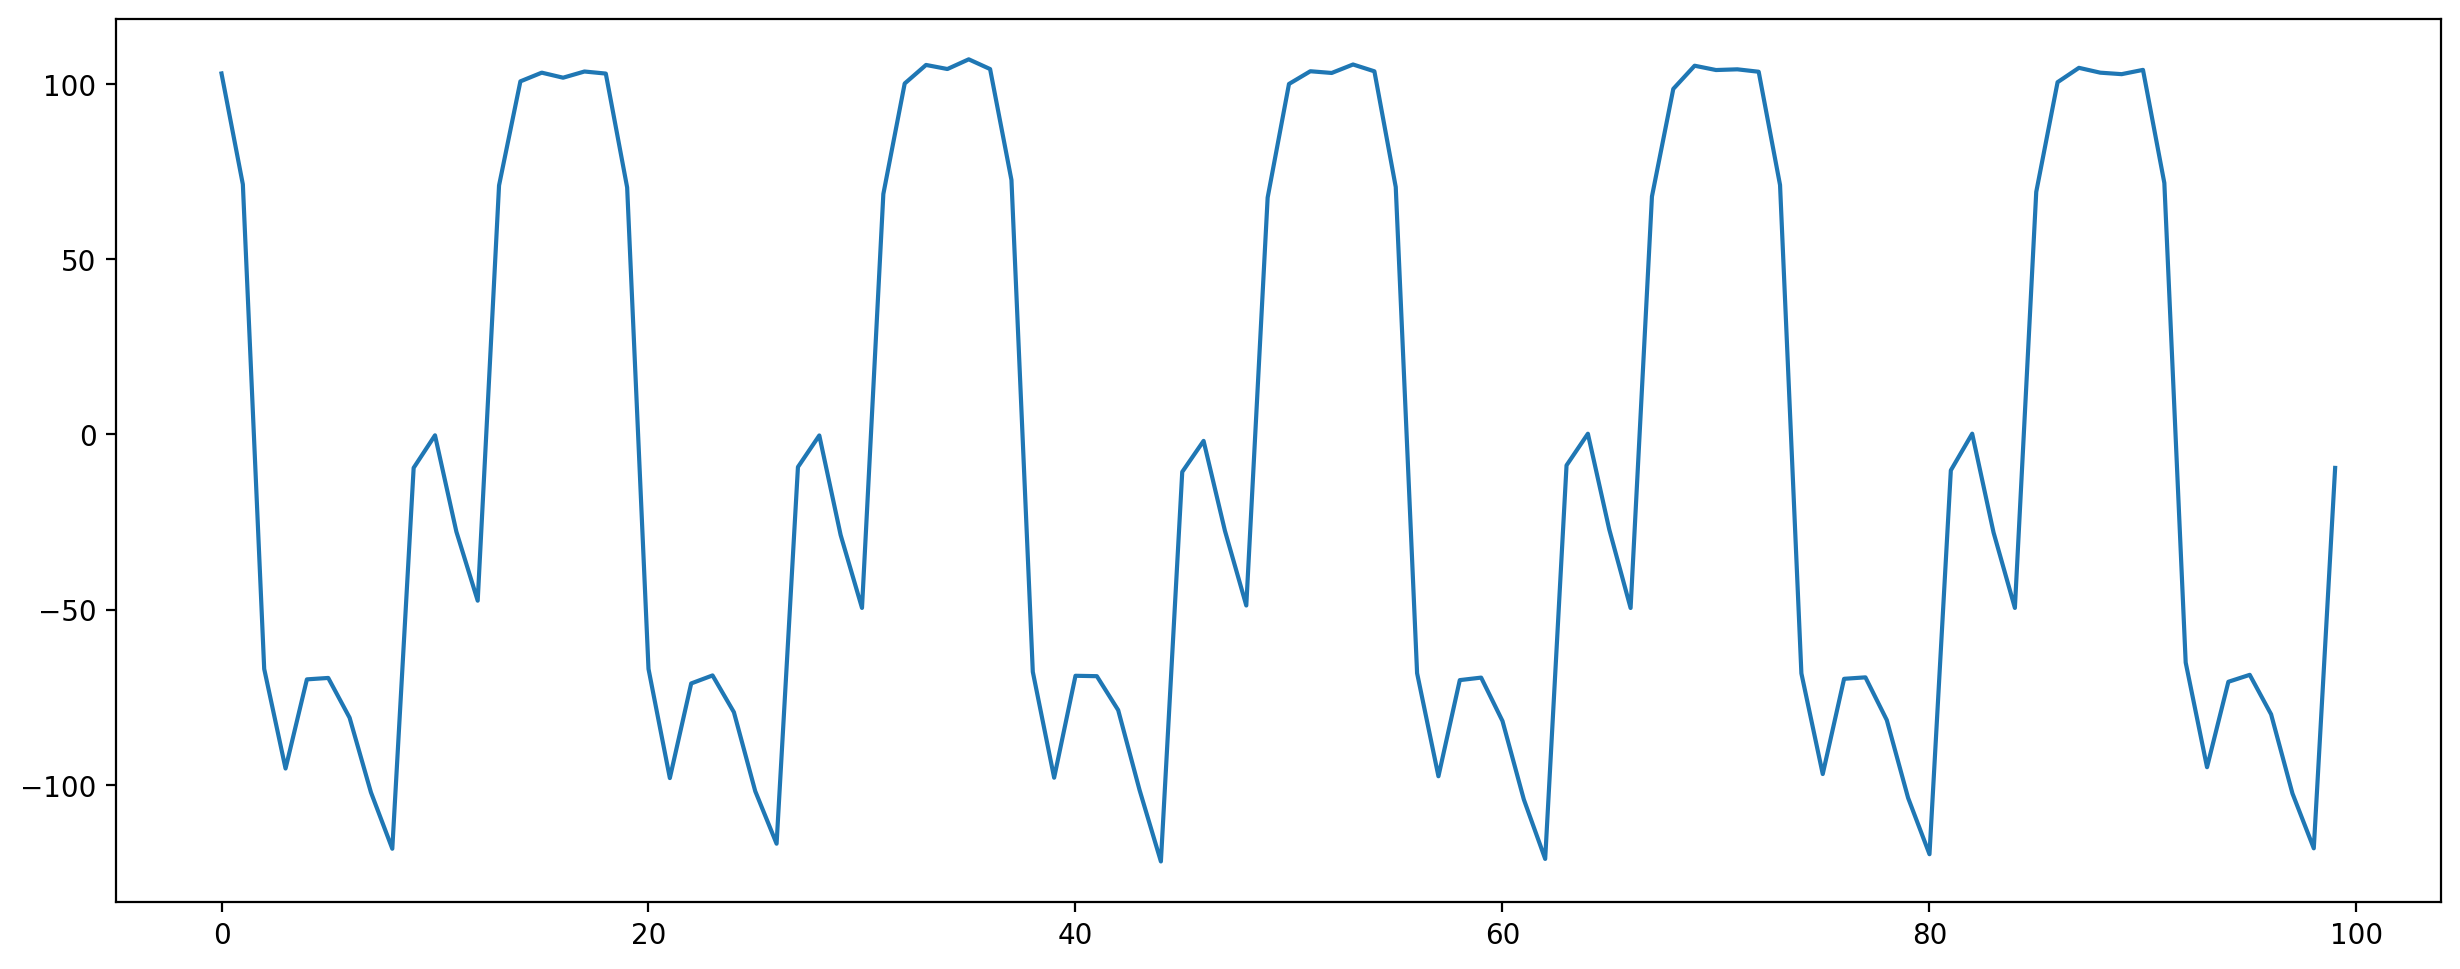

In [10]:
im_x = im.mean(axis=1)
im_x = np.roll(im_x, N_X//2) # avoid border effects
#im_x = np.correlate(im_x, [-1, 2, 1], 'same')*1. # contrast detection
im_x -= im_x.mean()
fig, ax = plt.subplots(figsize=(fig_width, fig_width/phi**2))
ax.plot(im_x[:100]);

Cross-correlation

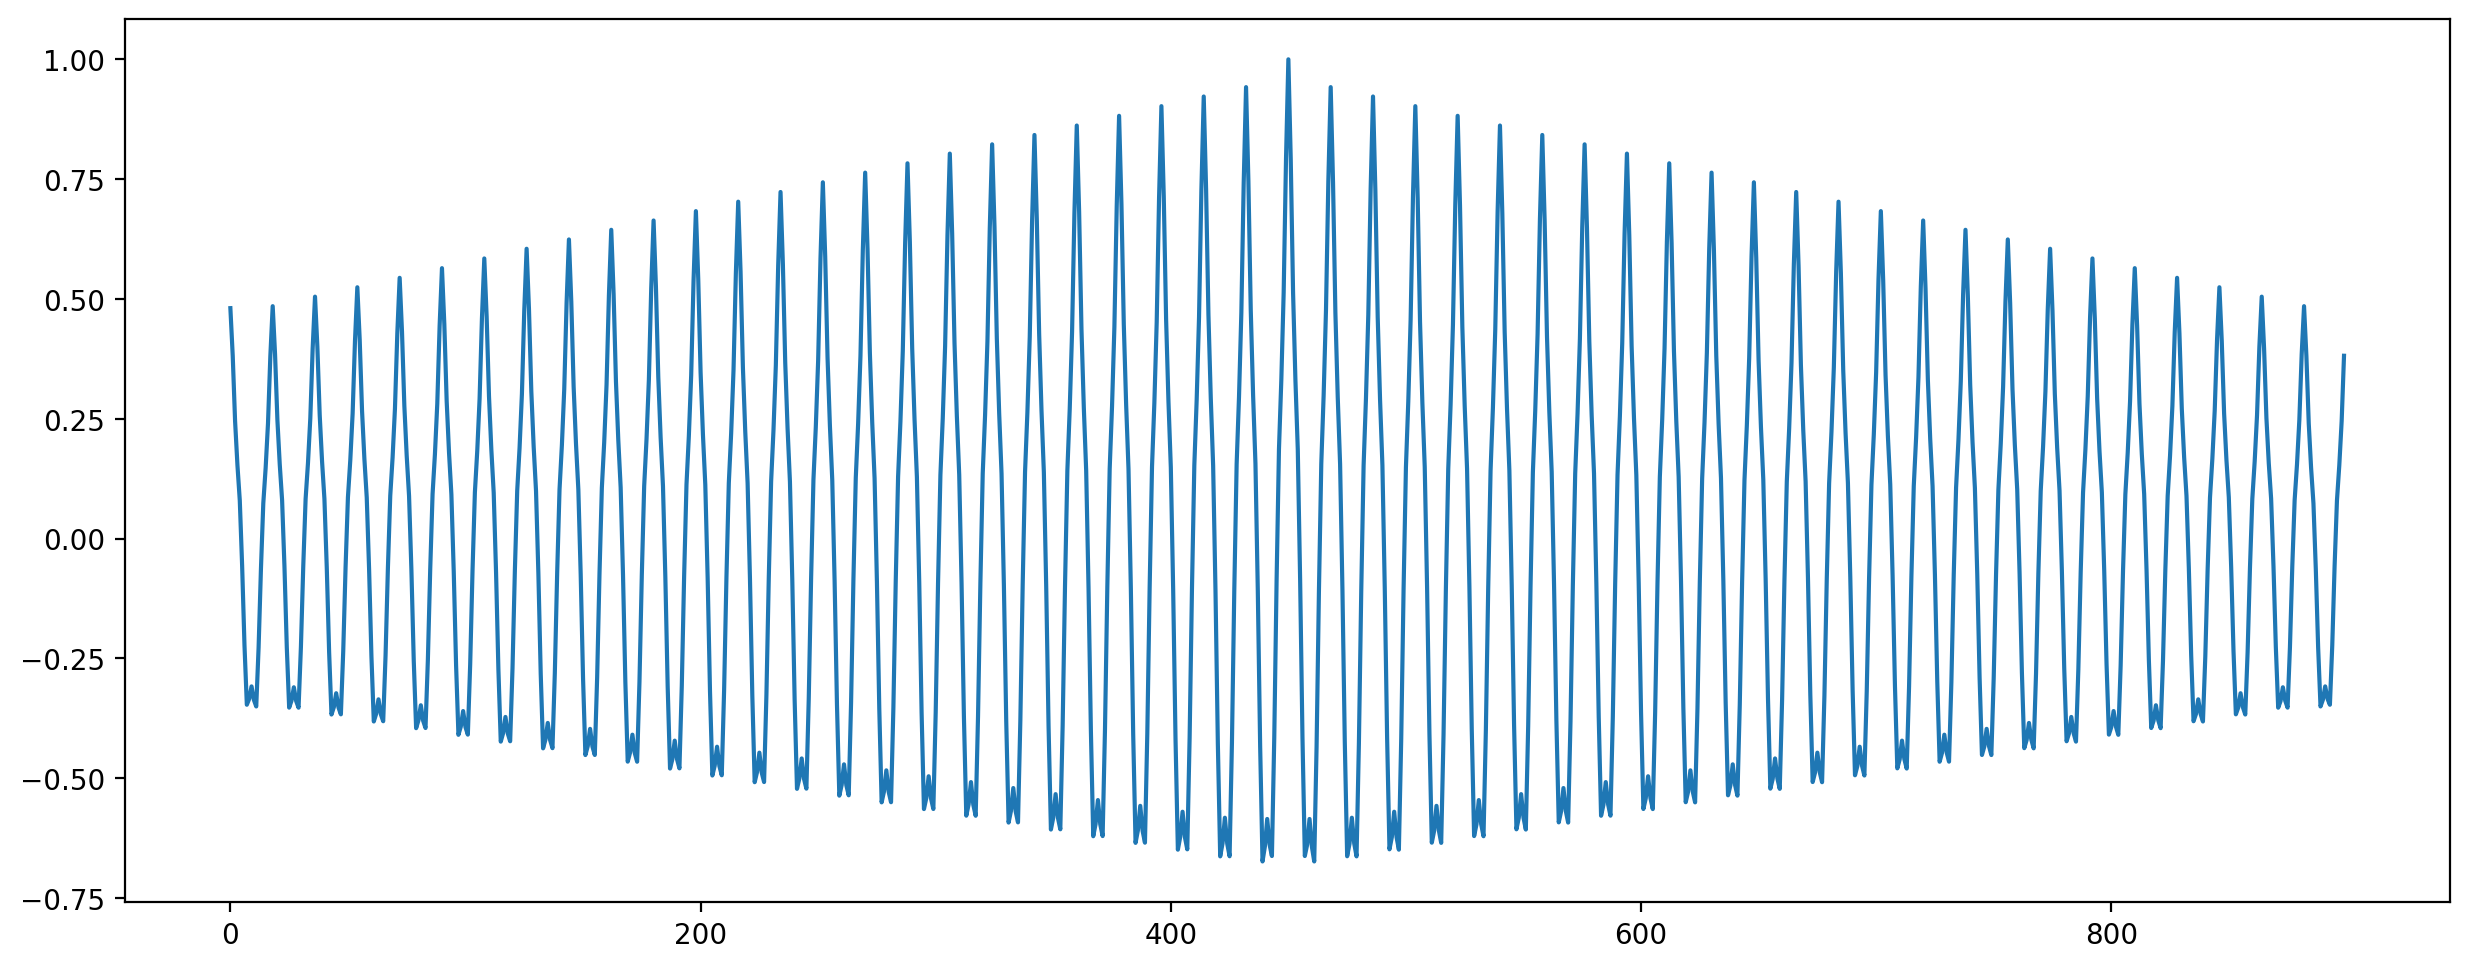

In [11]:
xcorr = np.correlate(im_x, im_x, 'same')*1.
xcorr /= xcorr.max()
fig, ax = plt.subplots(figsize=(fig_width, fig_width/phi**2))
ax.plot(xcorr);

In [12]:
N_X//2, im_x.shape, xcorr.shape, im.shape

(450, (900,), (900,), (900, 1146))

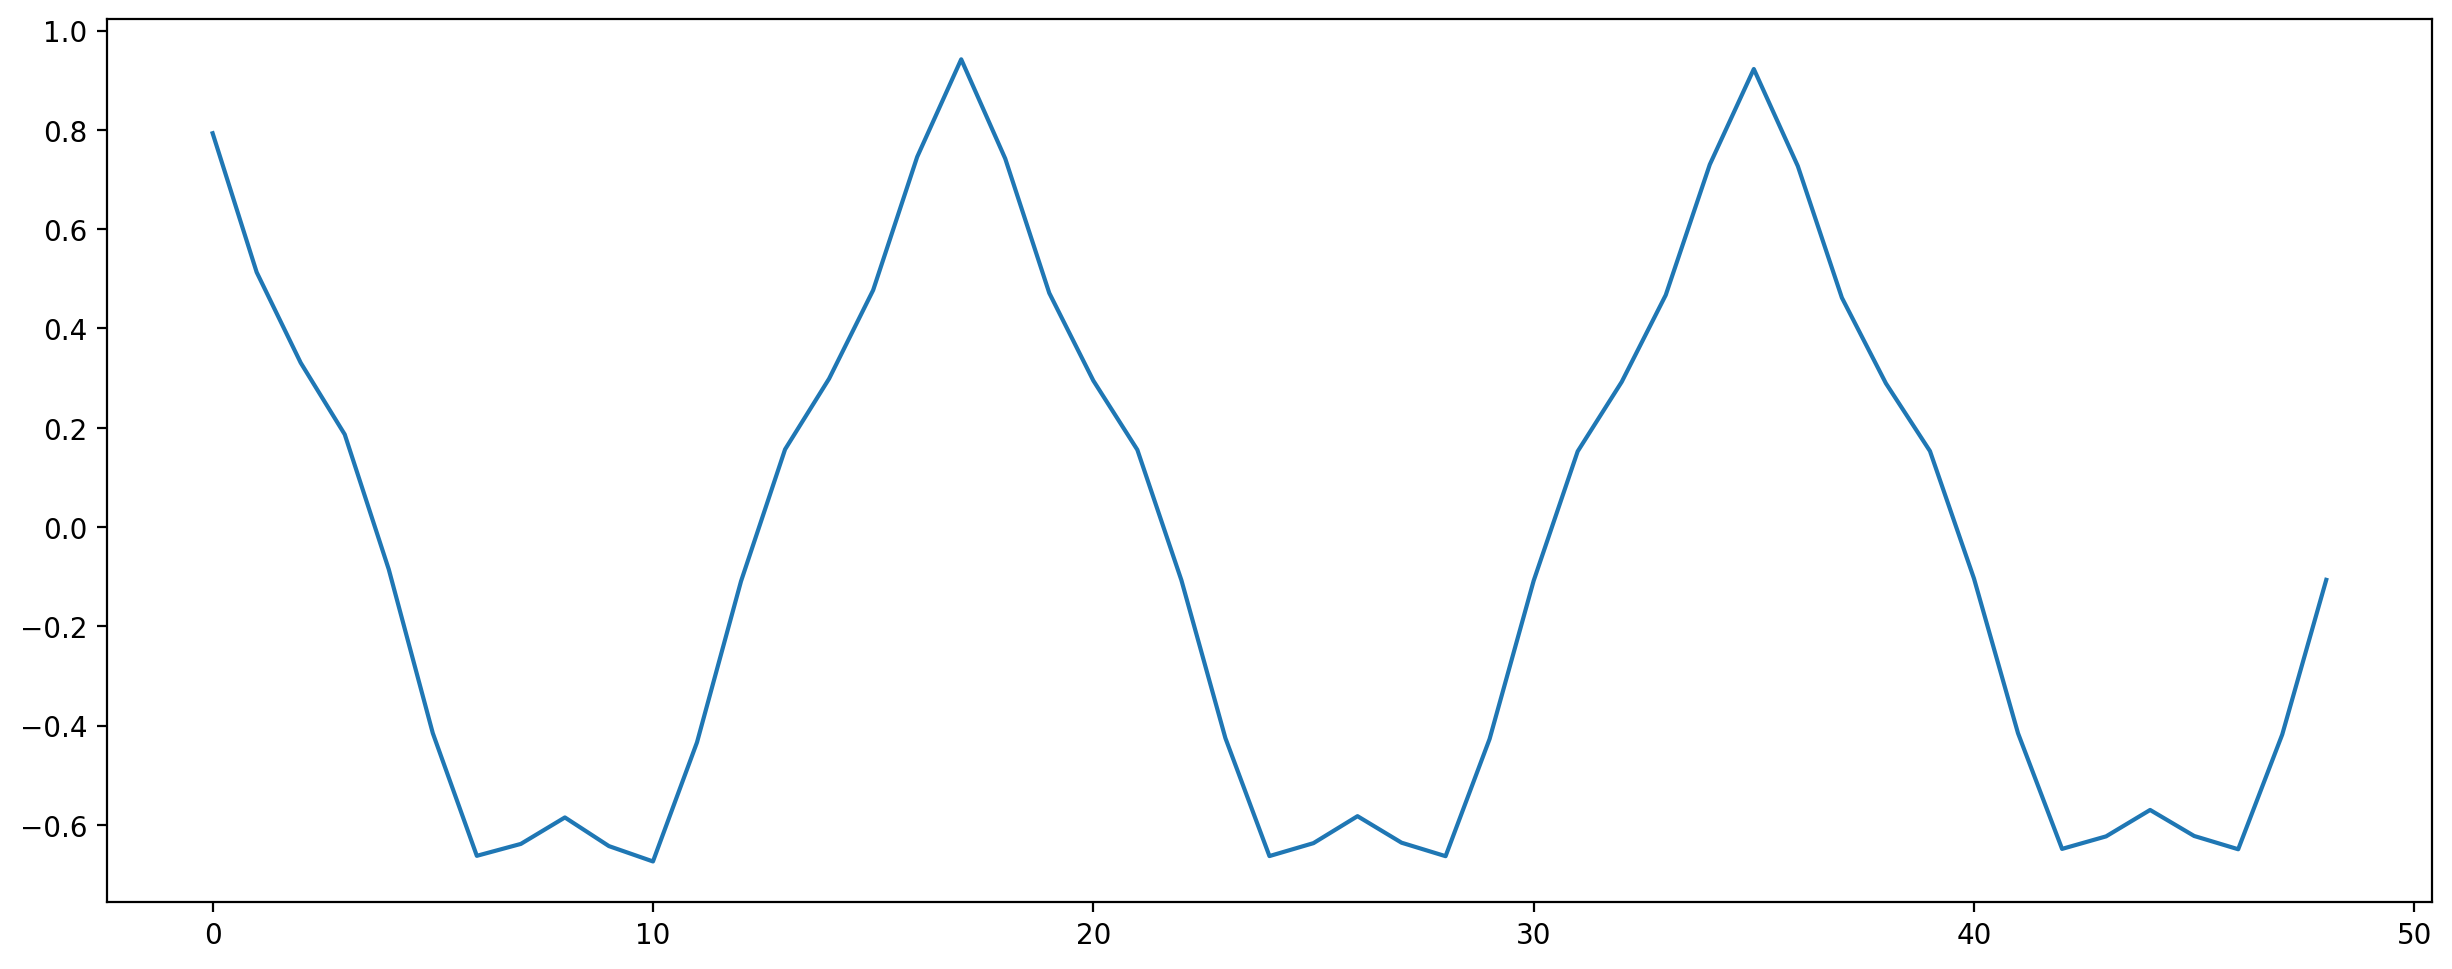

In [13]:
fig, ax = plt.subplots(figsize=(fig_width, fig_width/phi**2))
ax.plot(xcorr[(N_X//2+1):(50+N_X//2)]);

In [14]:
period_X = np.argmax(xcorr[(1+N_X//2):]) + 1

In [15]:
print(f'{period_X=}')

period_X=np.int64(18)


The other dimension:

In [16]:
im_y = im.mean(axis=0)
im_y -= im_y.mean()
#im_y[-1] = im_y[0]
#im_y[-2] = im_y[1]
im_y = np.roll(im_y, N_Y//2) # avoid border effects
#im_y = np.correlate(im_y, [-1, 2, -1], 'same')*1. # contrast detection

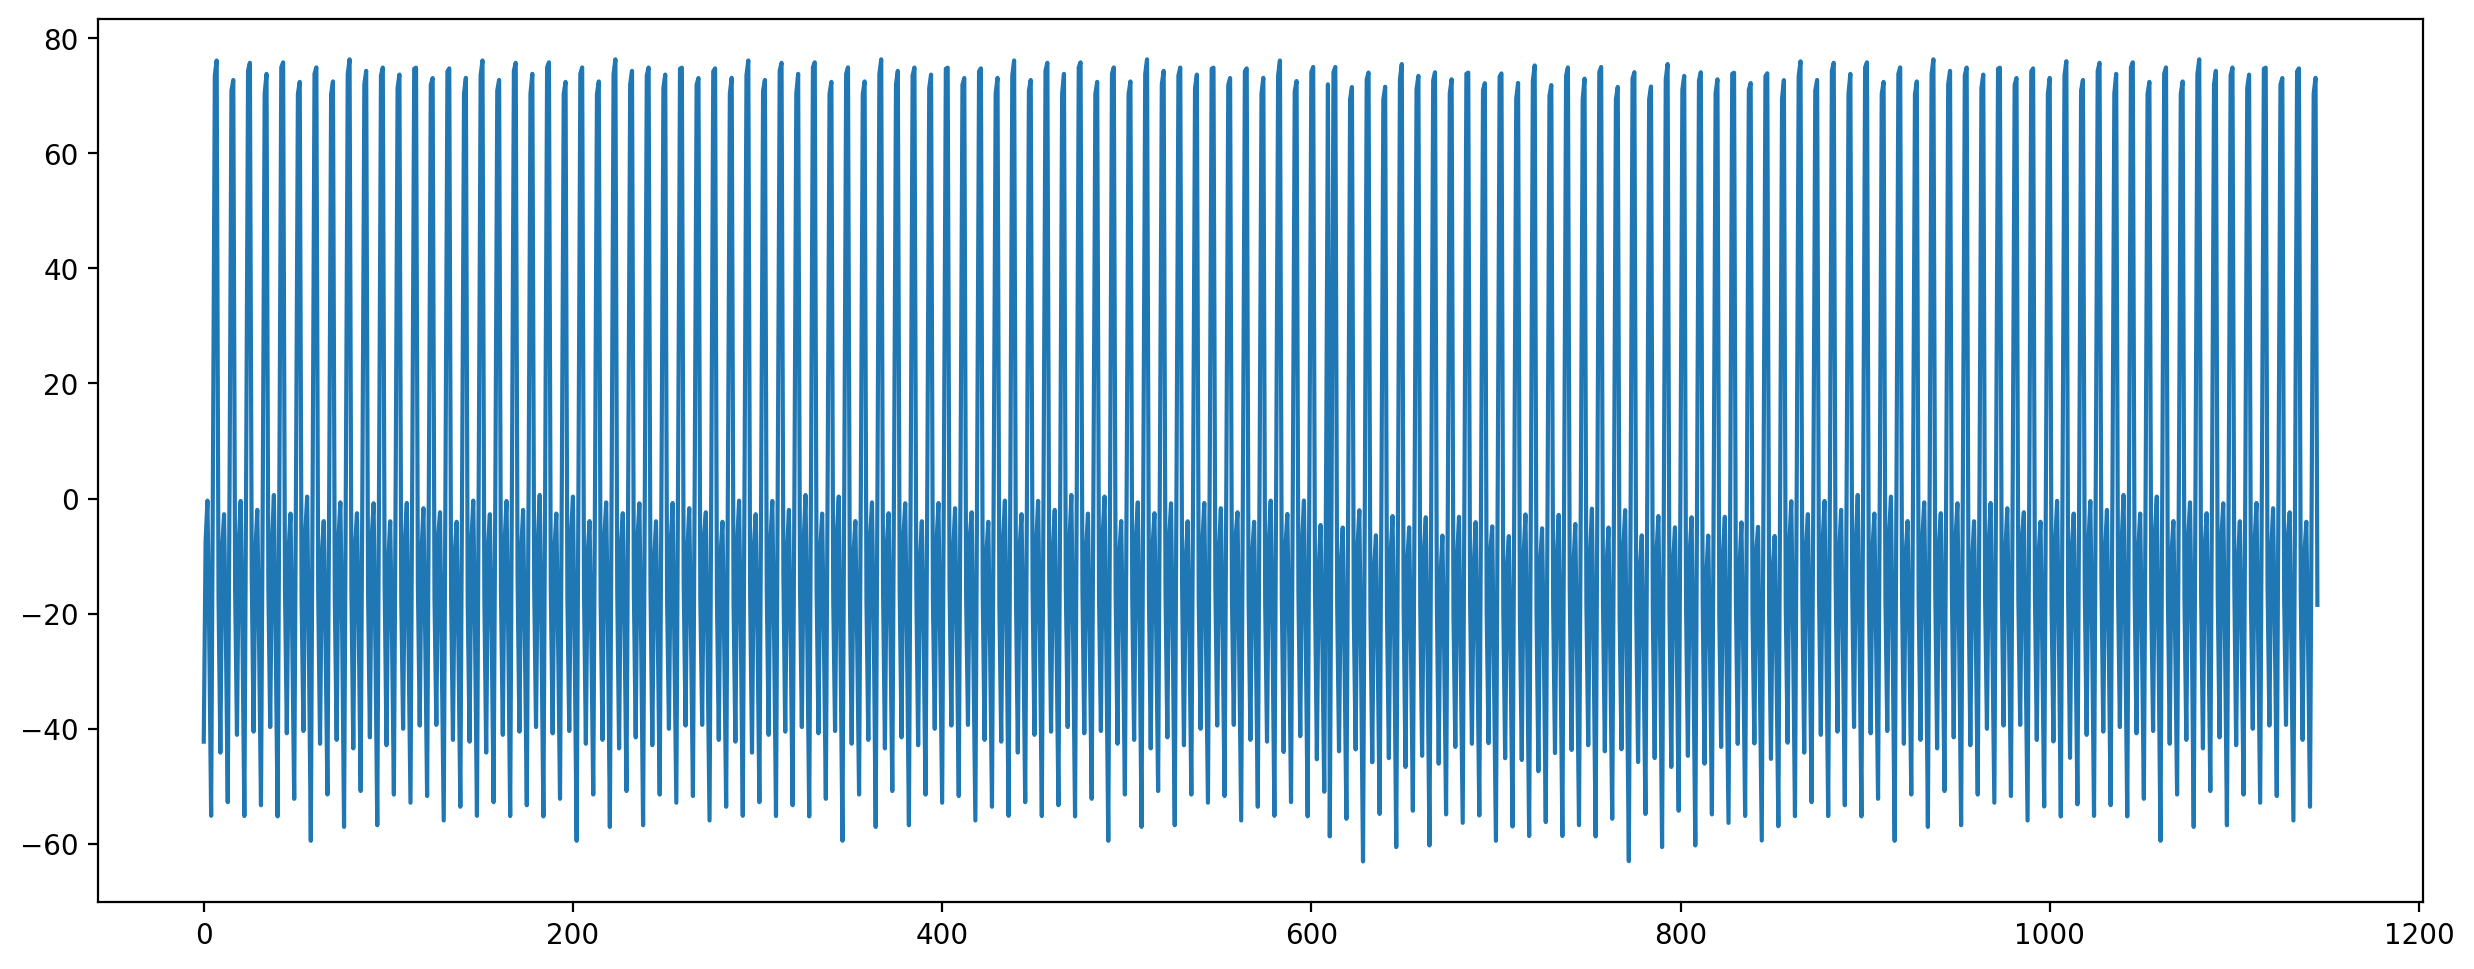

In [17]:
fig, ax = plt.subplots(figsize=(fig_width, fig_width/phi**2))
ax.plot(im_y);

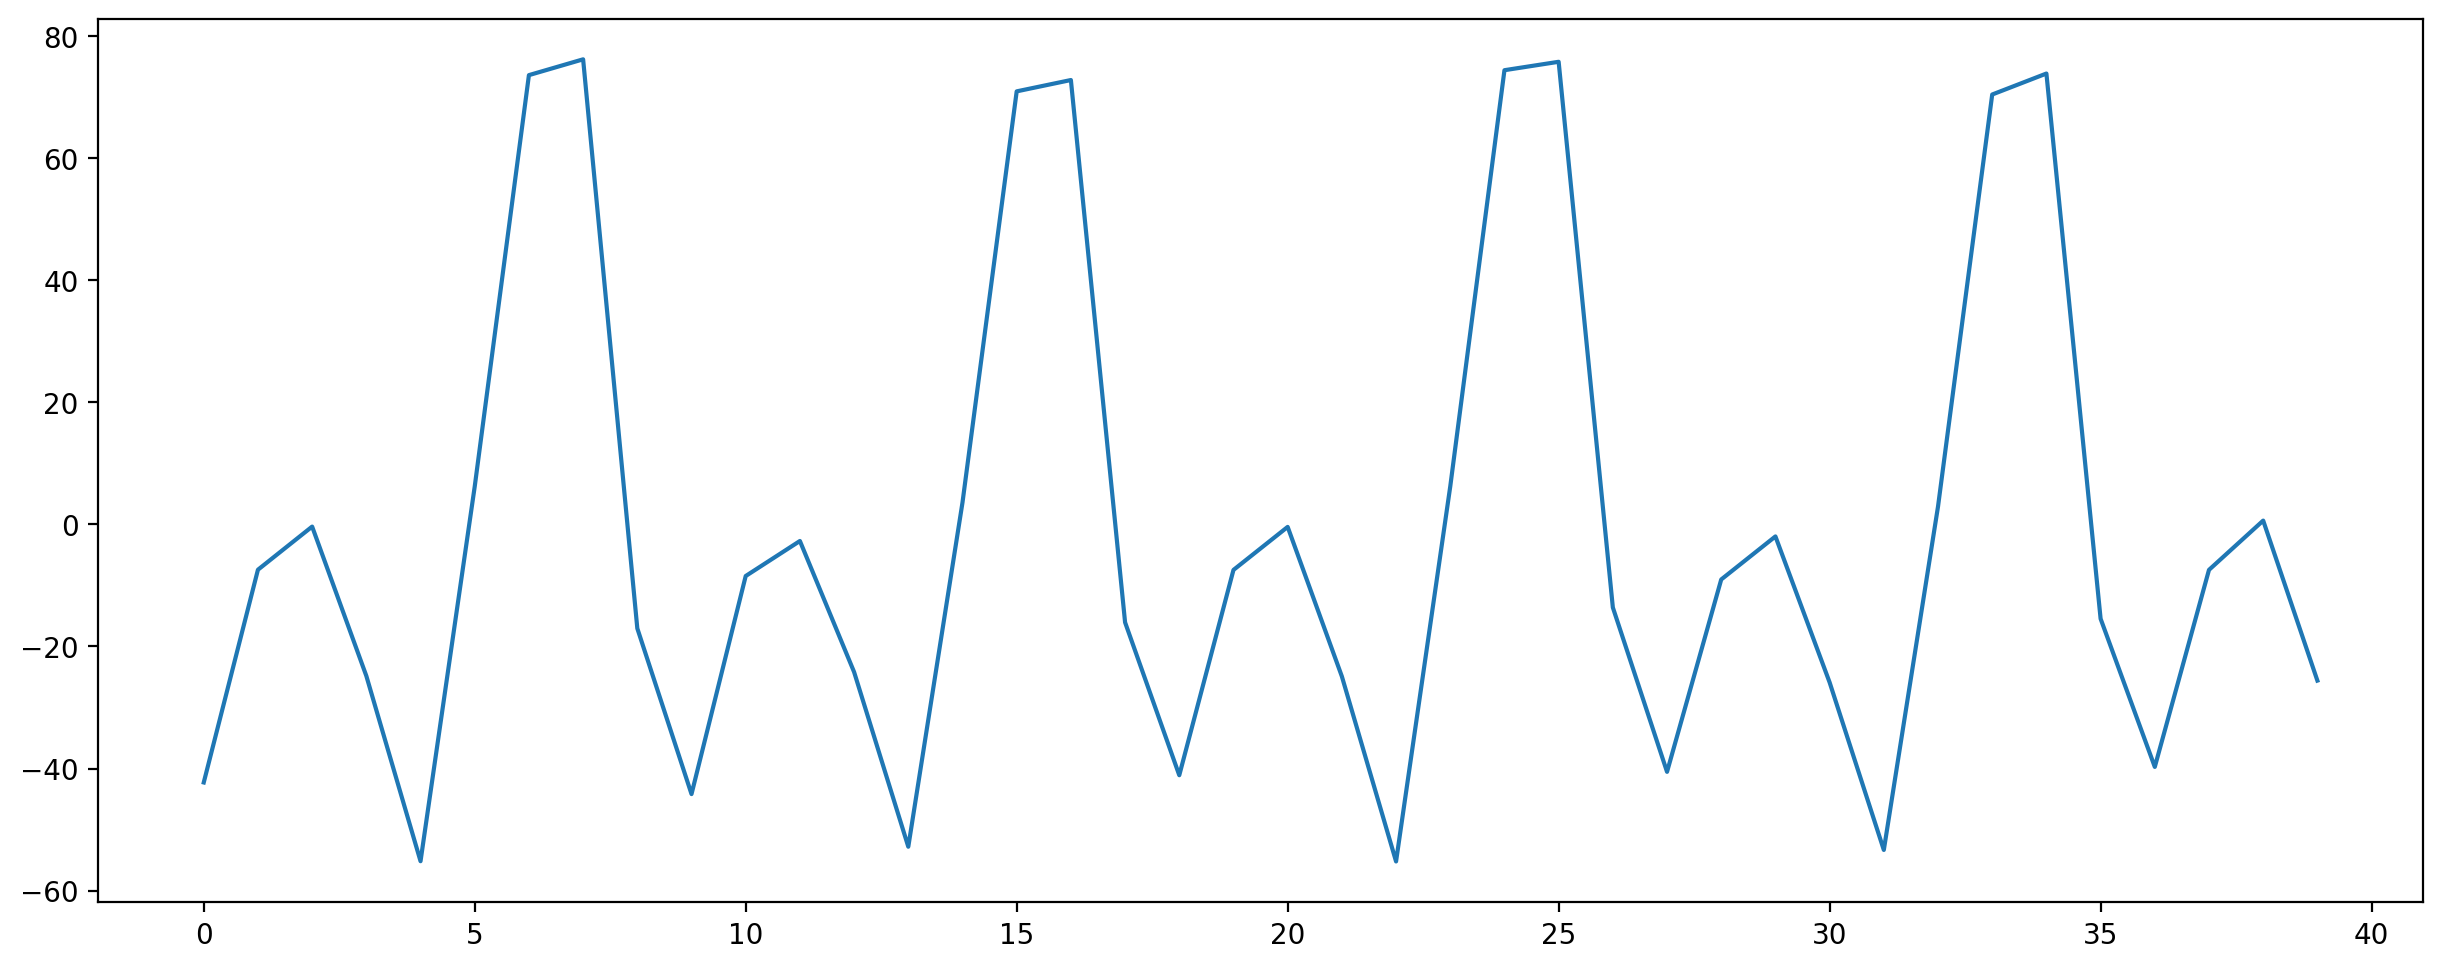

In [18]:
fig, ax = plt.subplots(figsize=(fig_width, fig_width/phi**2))
ax.plot(im_y[:40]);

In [19]:
xcorr = np.correlate(im_y, im_y, 'same')*1.

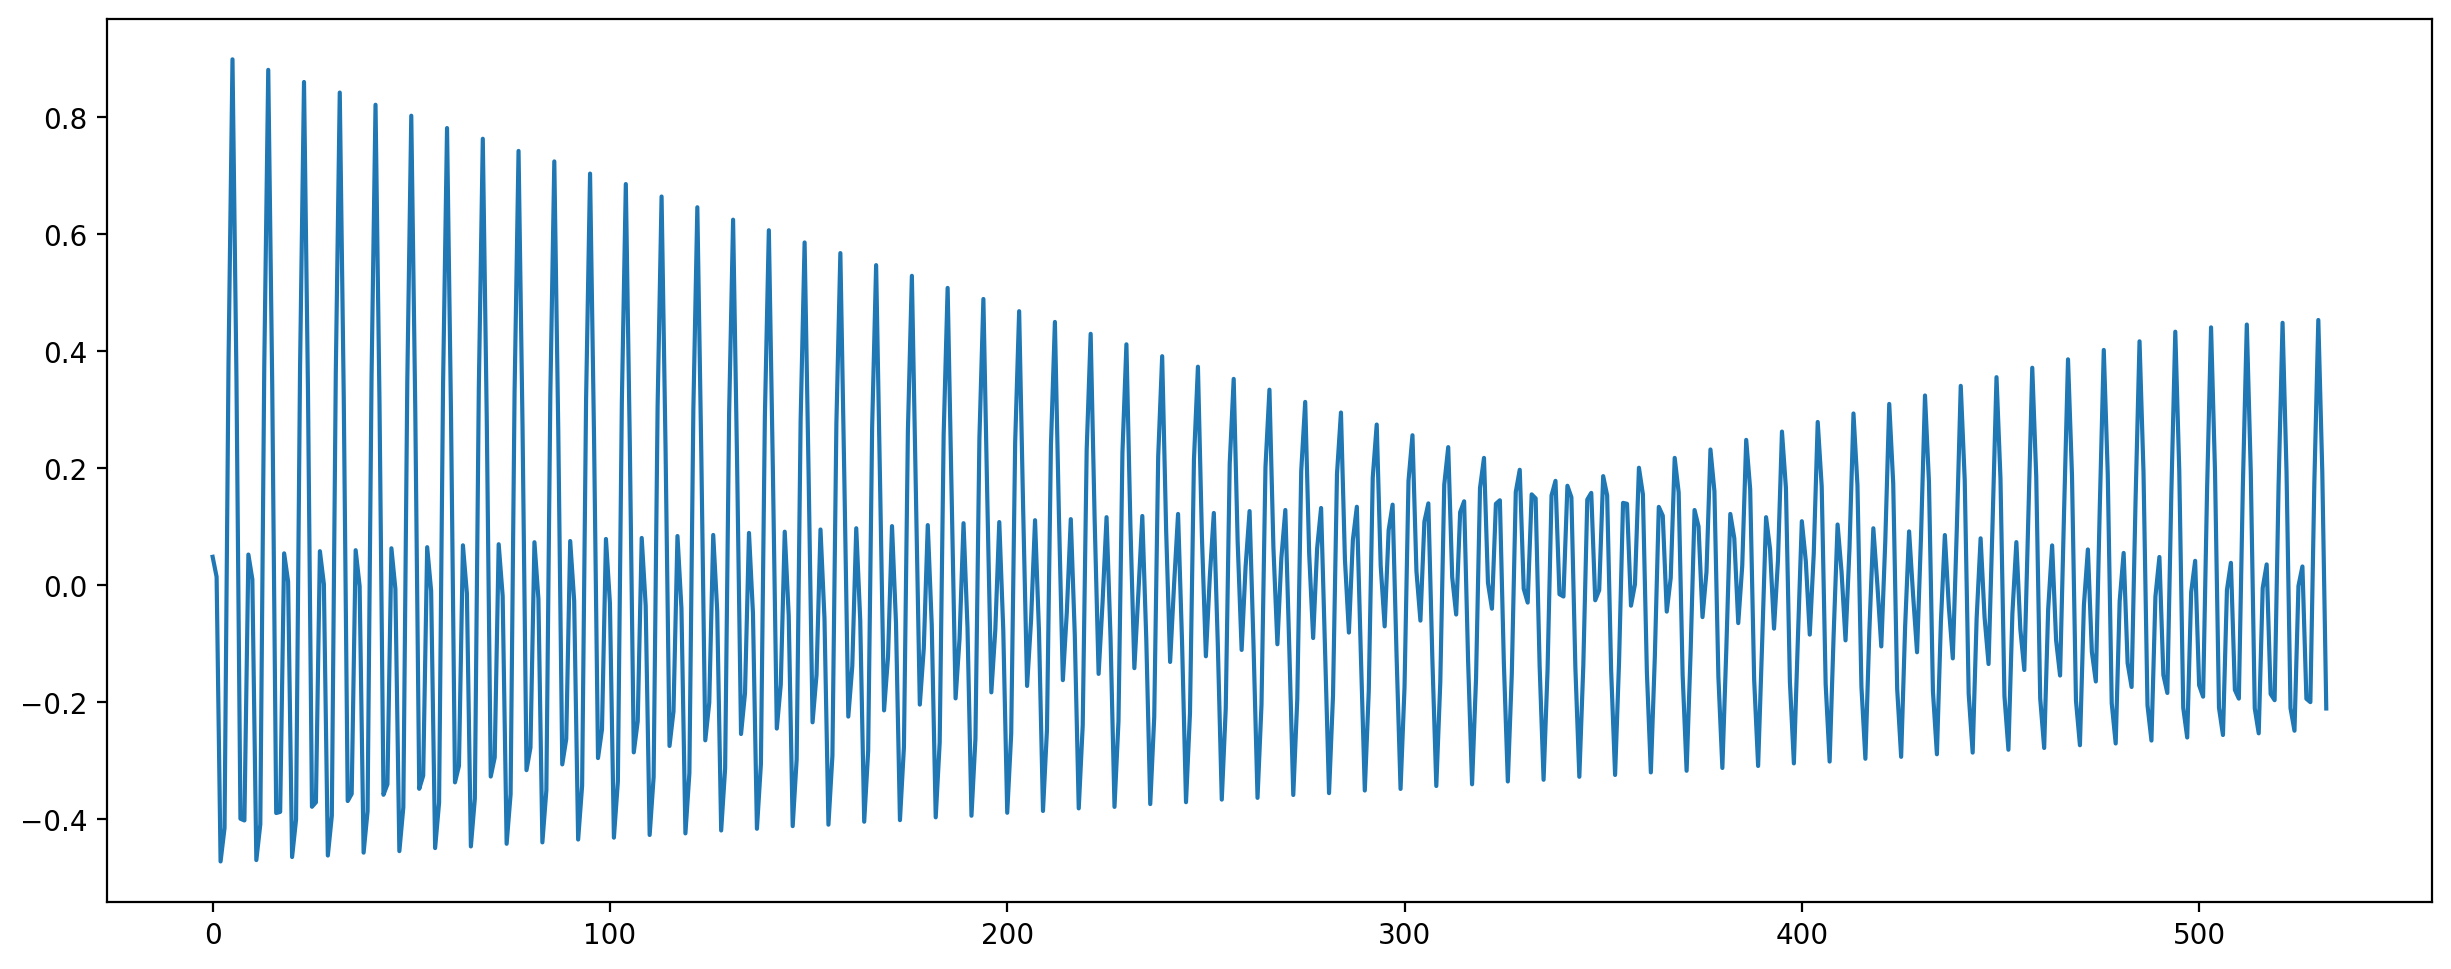

In [20]:
xcorr /= xcorr.max()
fig, ax = plt.subplots(figsize=(fig_width, fig_width/phi**2))
ax.plot(xcorr[(N_Y//2+3):]);

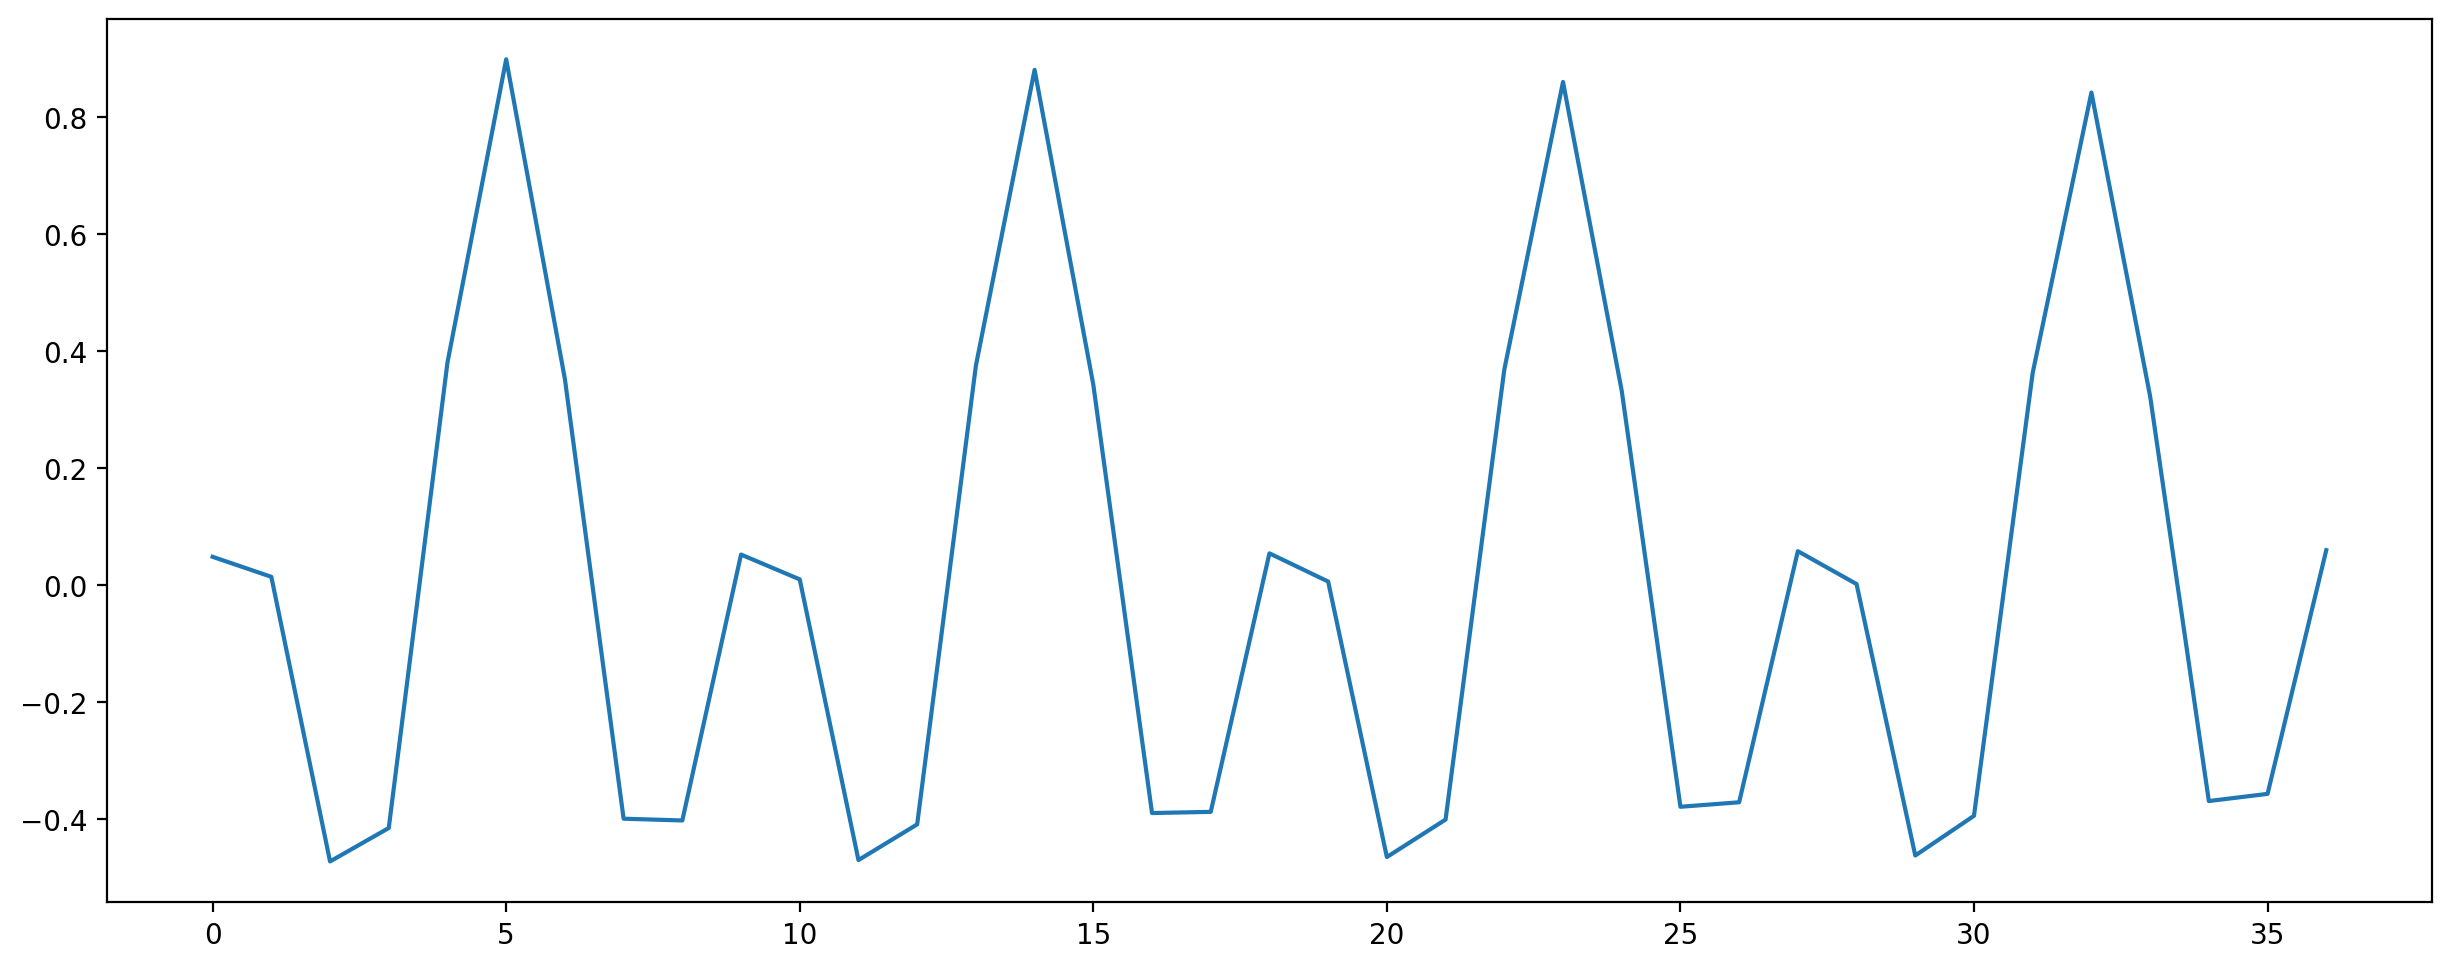

In [21]:
xcorr /= xcorr.max()
fig, ax = plt.subplots(figsize=(fig_width, fig_width/phi**2))
ax.plot(xcorr[(N_Y//2+3):(40+N_Y//2)]);

In [22]:
period_Y = np.argmax(xcorr[(3+N_Y//2):]) + 3

In [23]:
print(f'{period_Y=}')

period_Y=np.int64(8)


One sample (other random choices would *most probably* fit - do not go in the borders!)

In [24]:
idx, idy = 0, 21
kernel = im[idx:idx+period_X, idy:idy+period_Y]

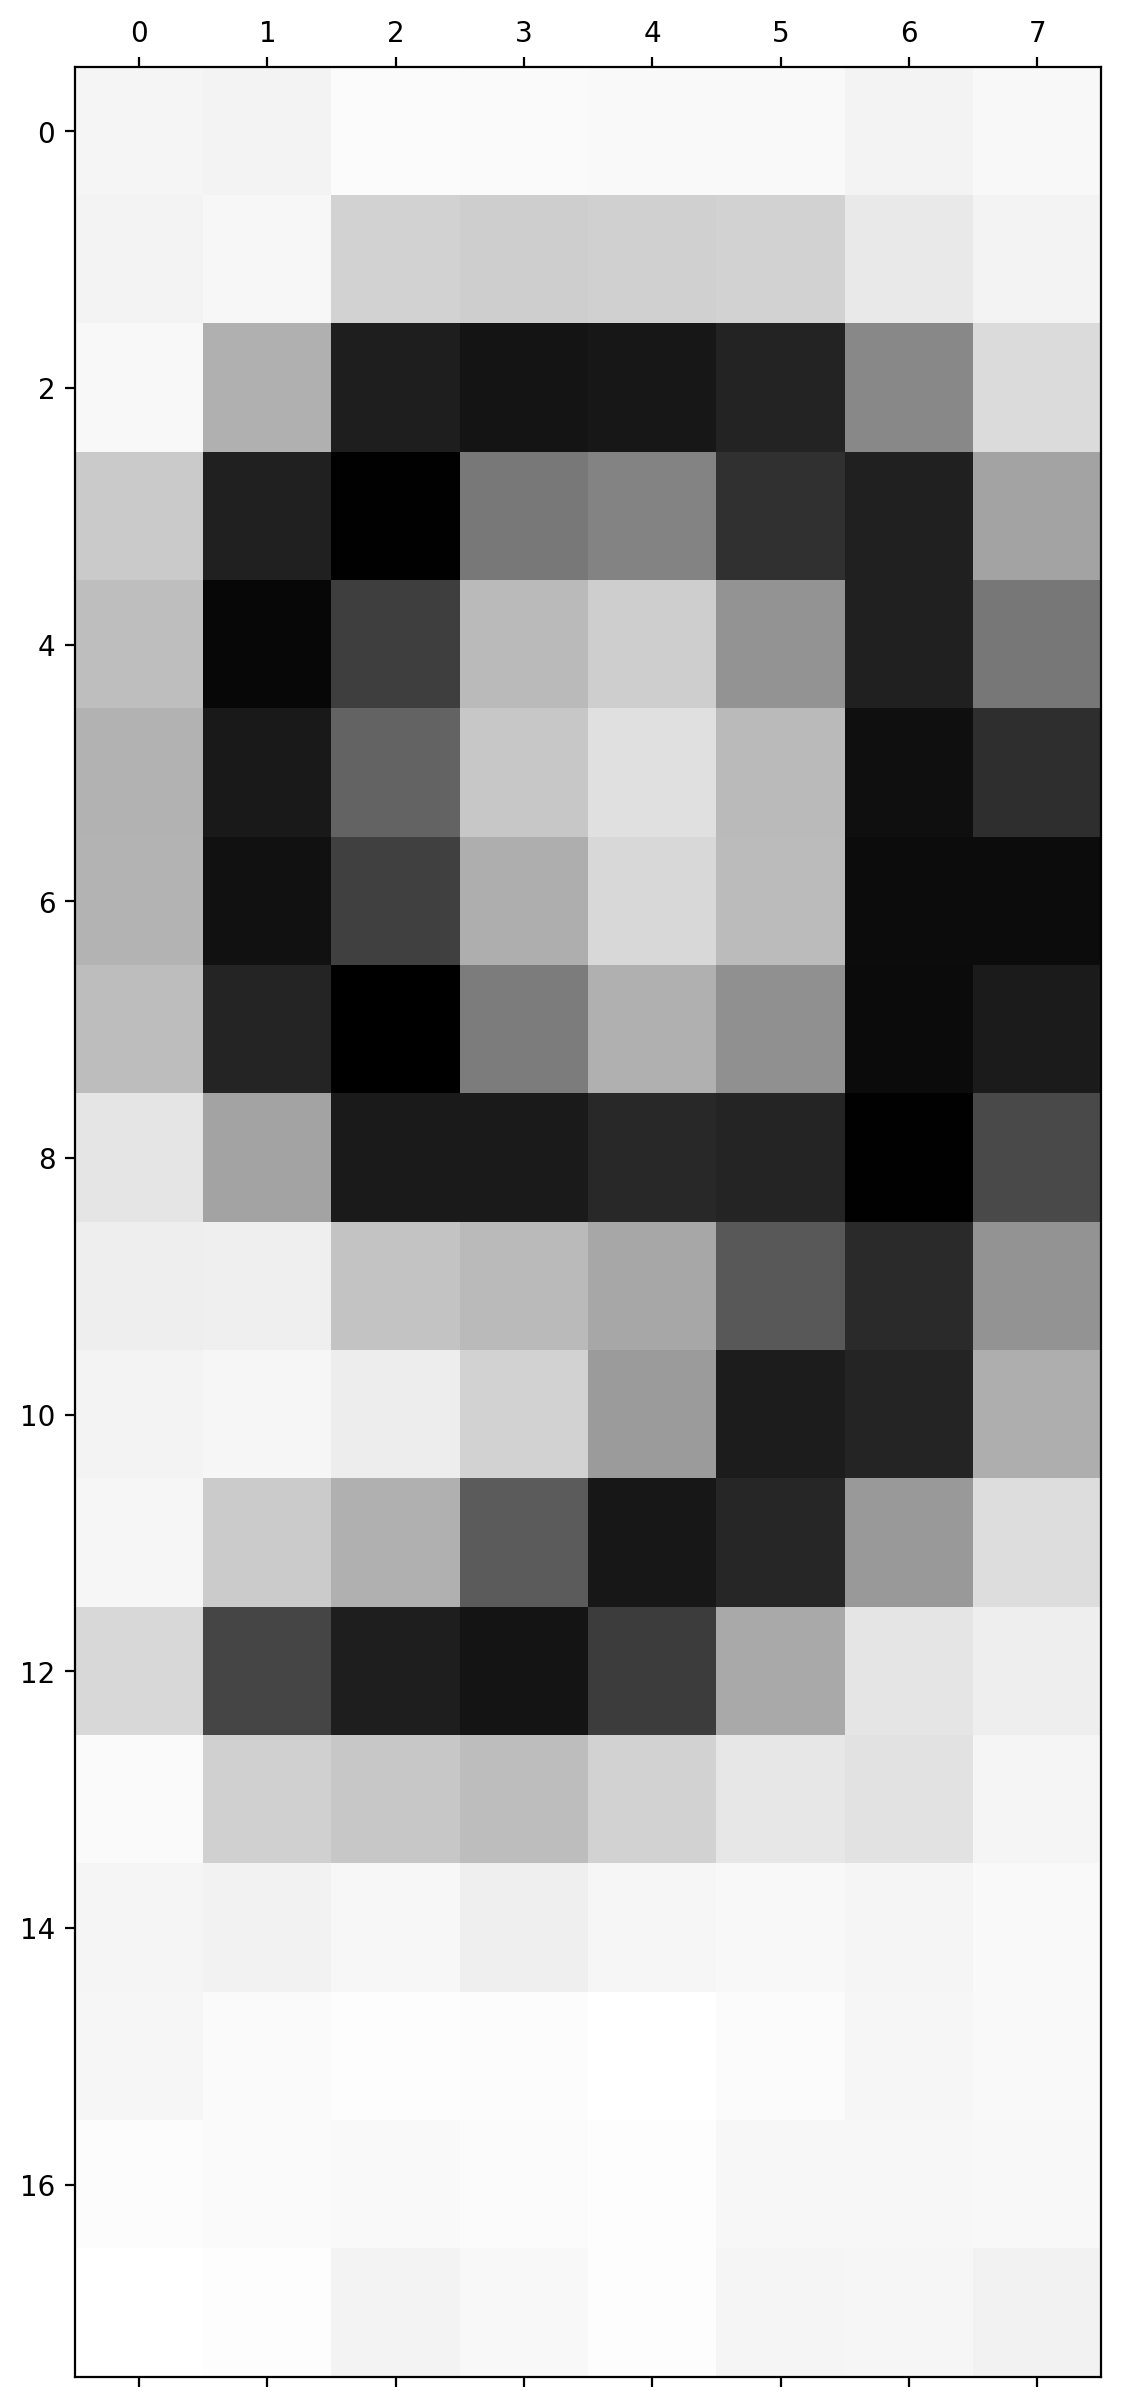

In [25]:
fig, ax = plt.subplots(figsize=(fig_width, fig_width))
ax.matshow(kernel);

compute cross correlation using one of these variants : 
https://laurentperrinet.github.io//sciblog/posts/2017-09-20-the-fastest-2d-convolution-in-the-world.html


In [26]:
from scipy import ndimage

# Perform the convolution
xcorr = ndimage.convolve(im*1., kernel, mode='wrap')
xcorr /= xcorr.max()

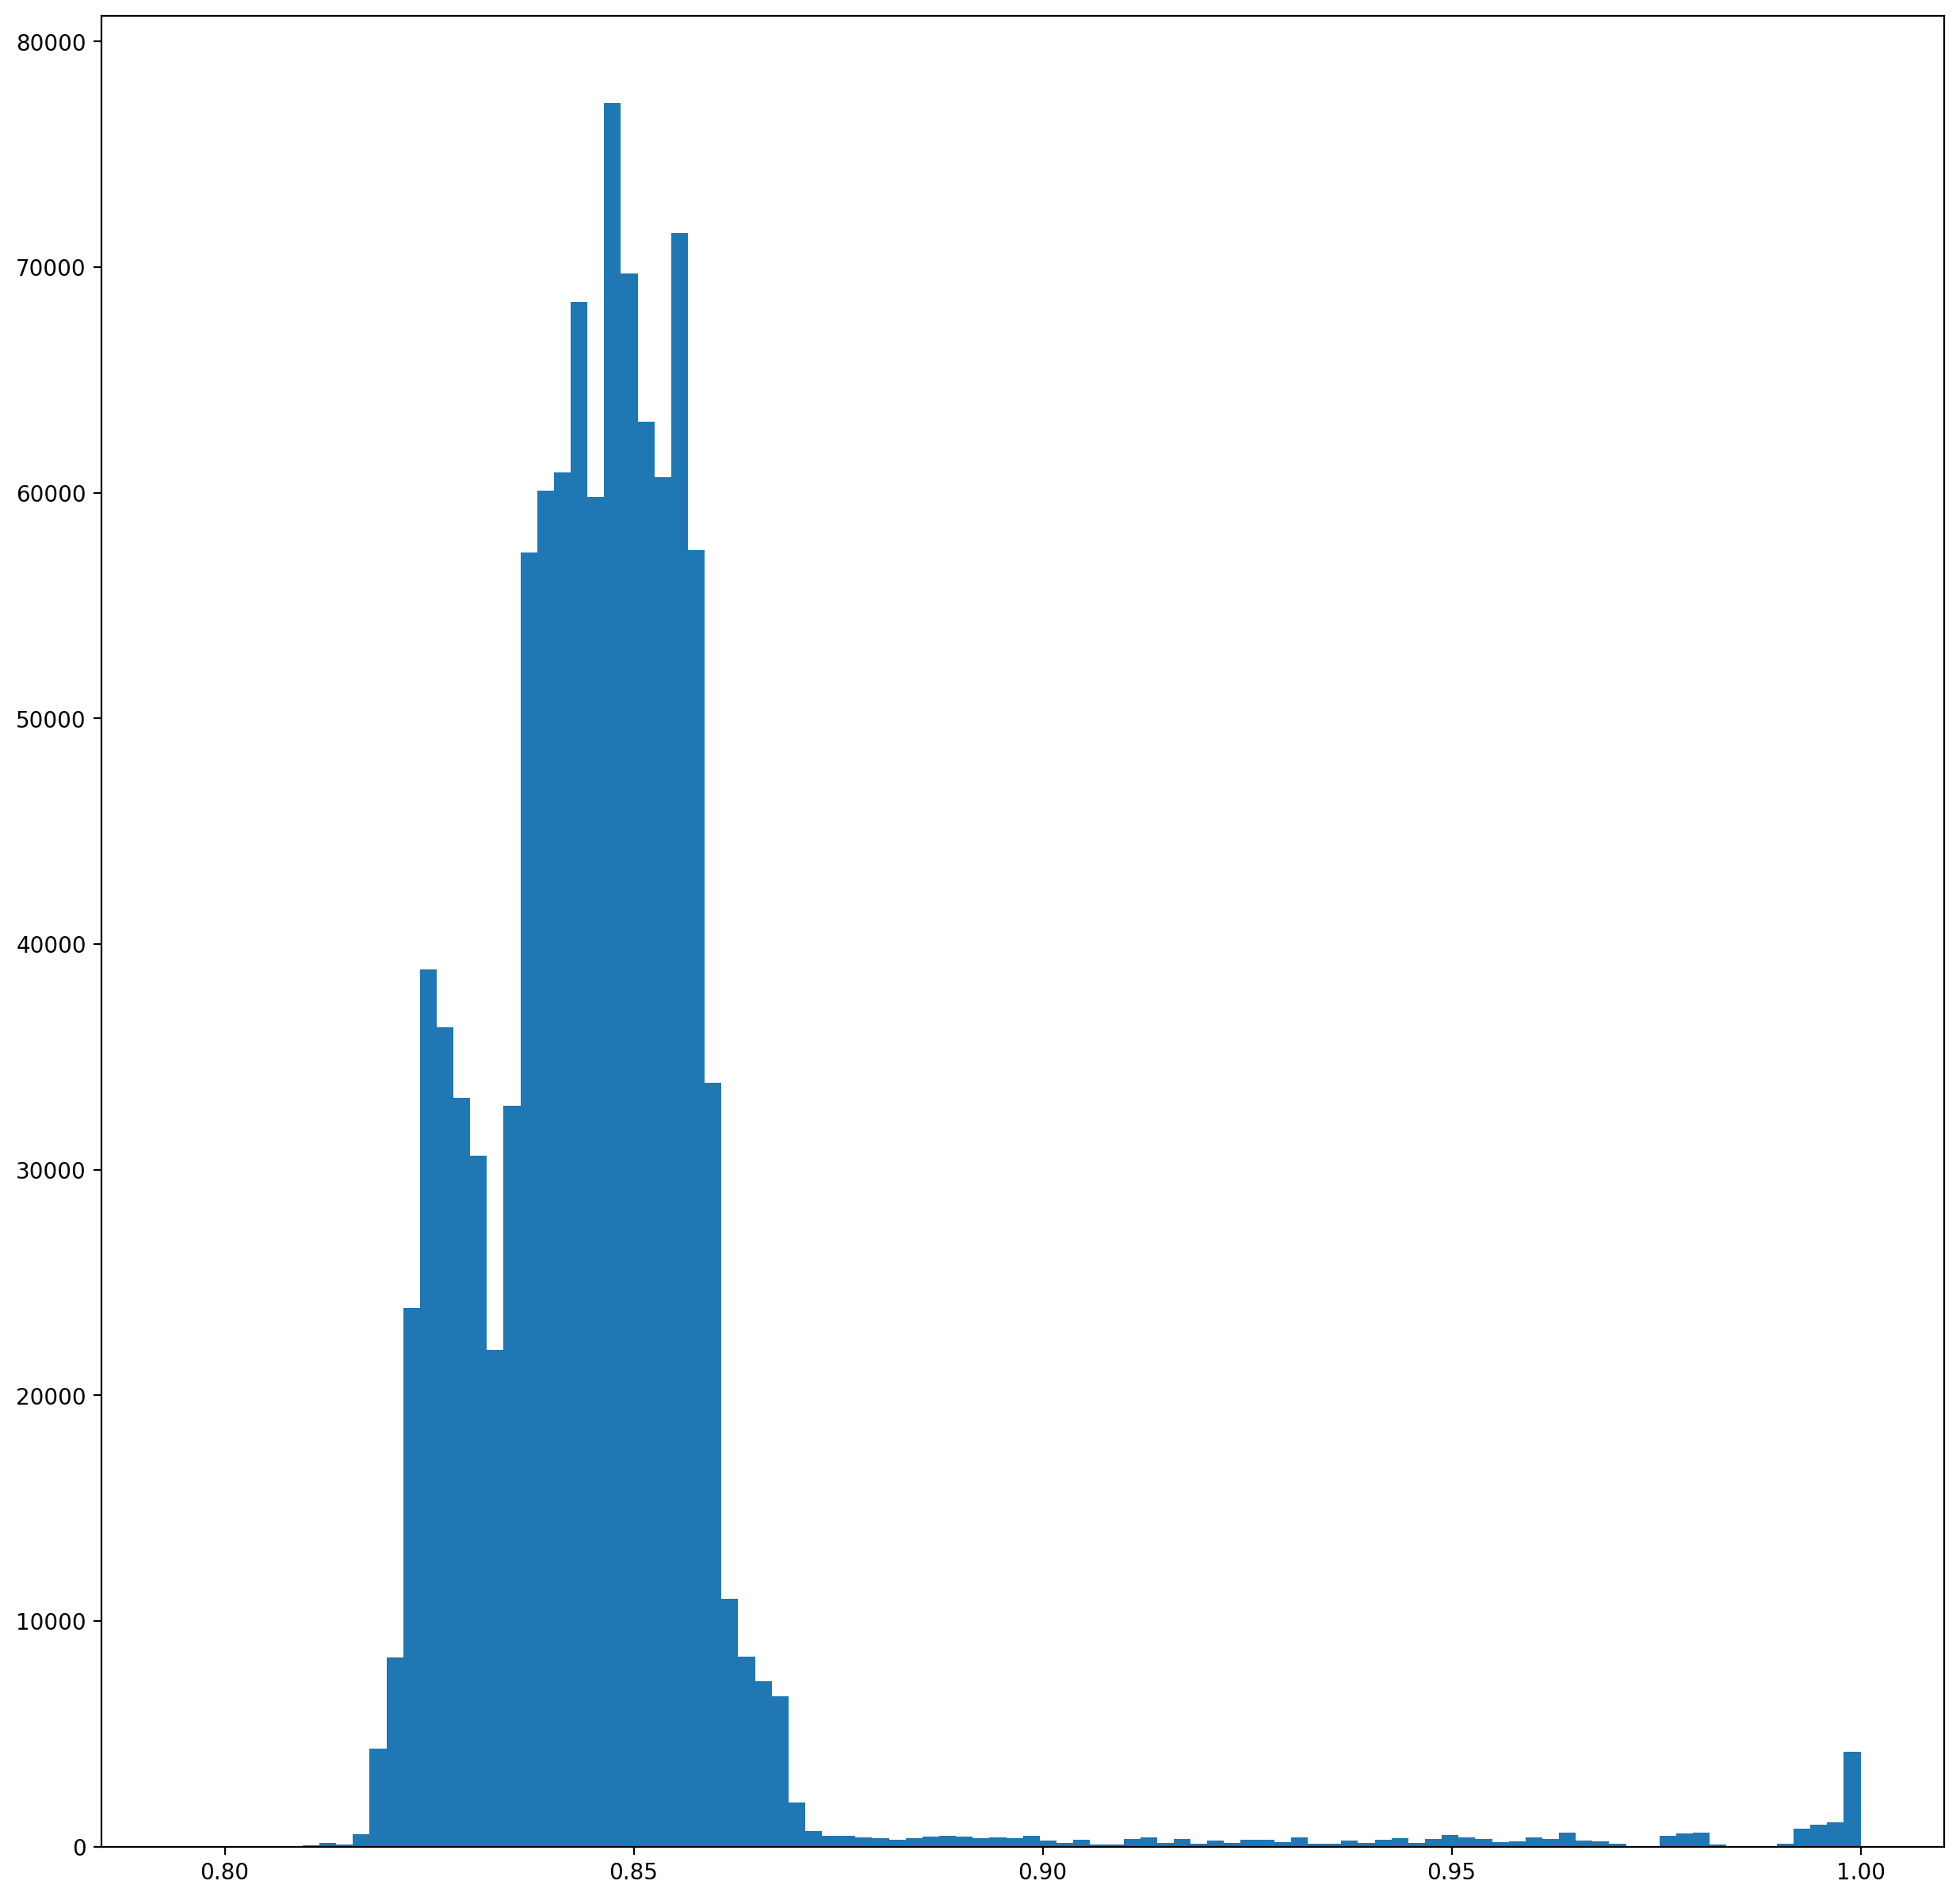

In [27]:
fig, ax = plt.subplots(figsize=(fig_width, fig_width))
ax.hist(xcorr.ravel(), bins=100);

Now you can spot where there is a difference (and then in the rest due to kerning...)

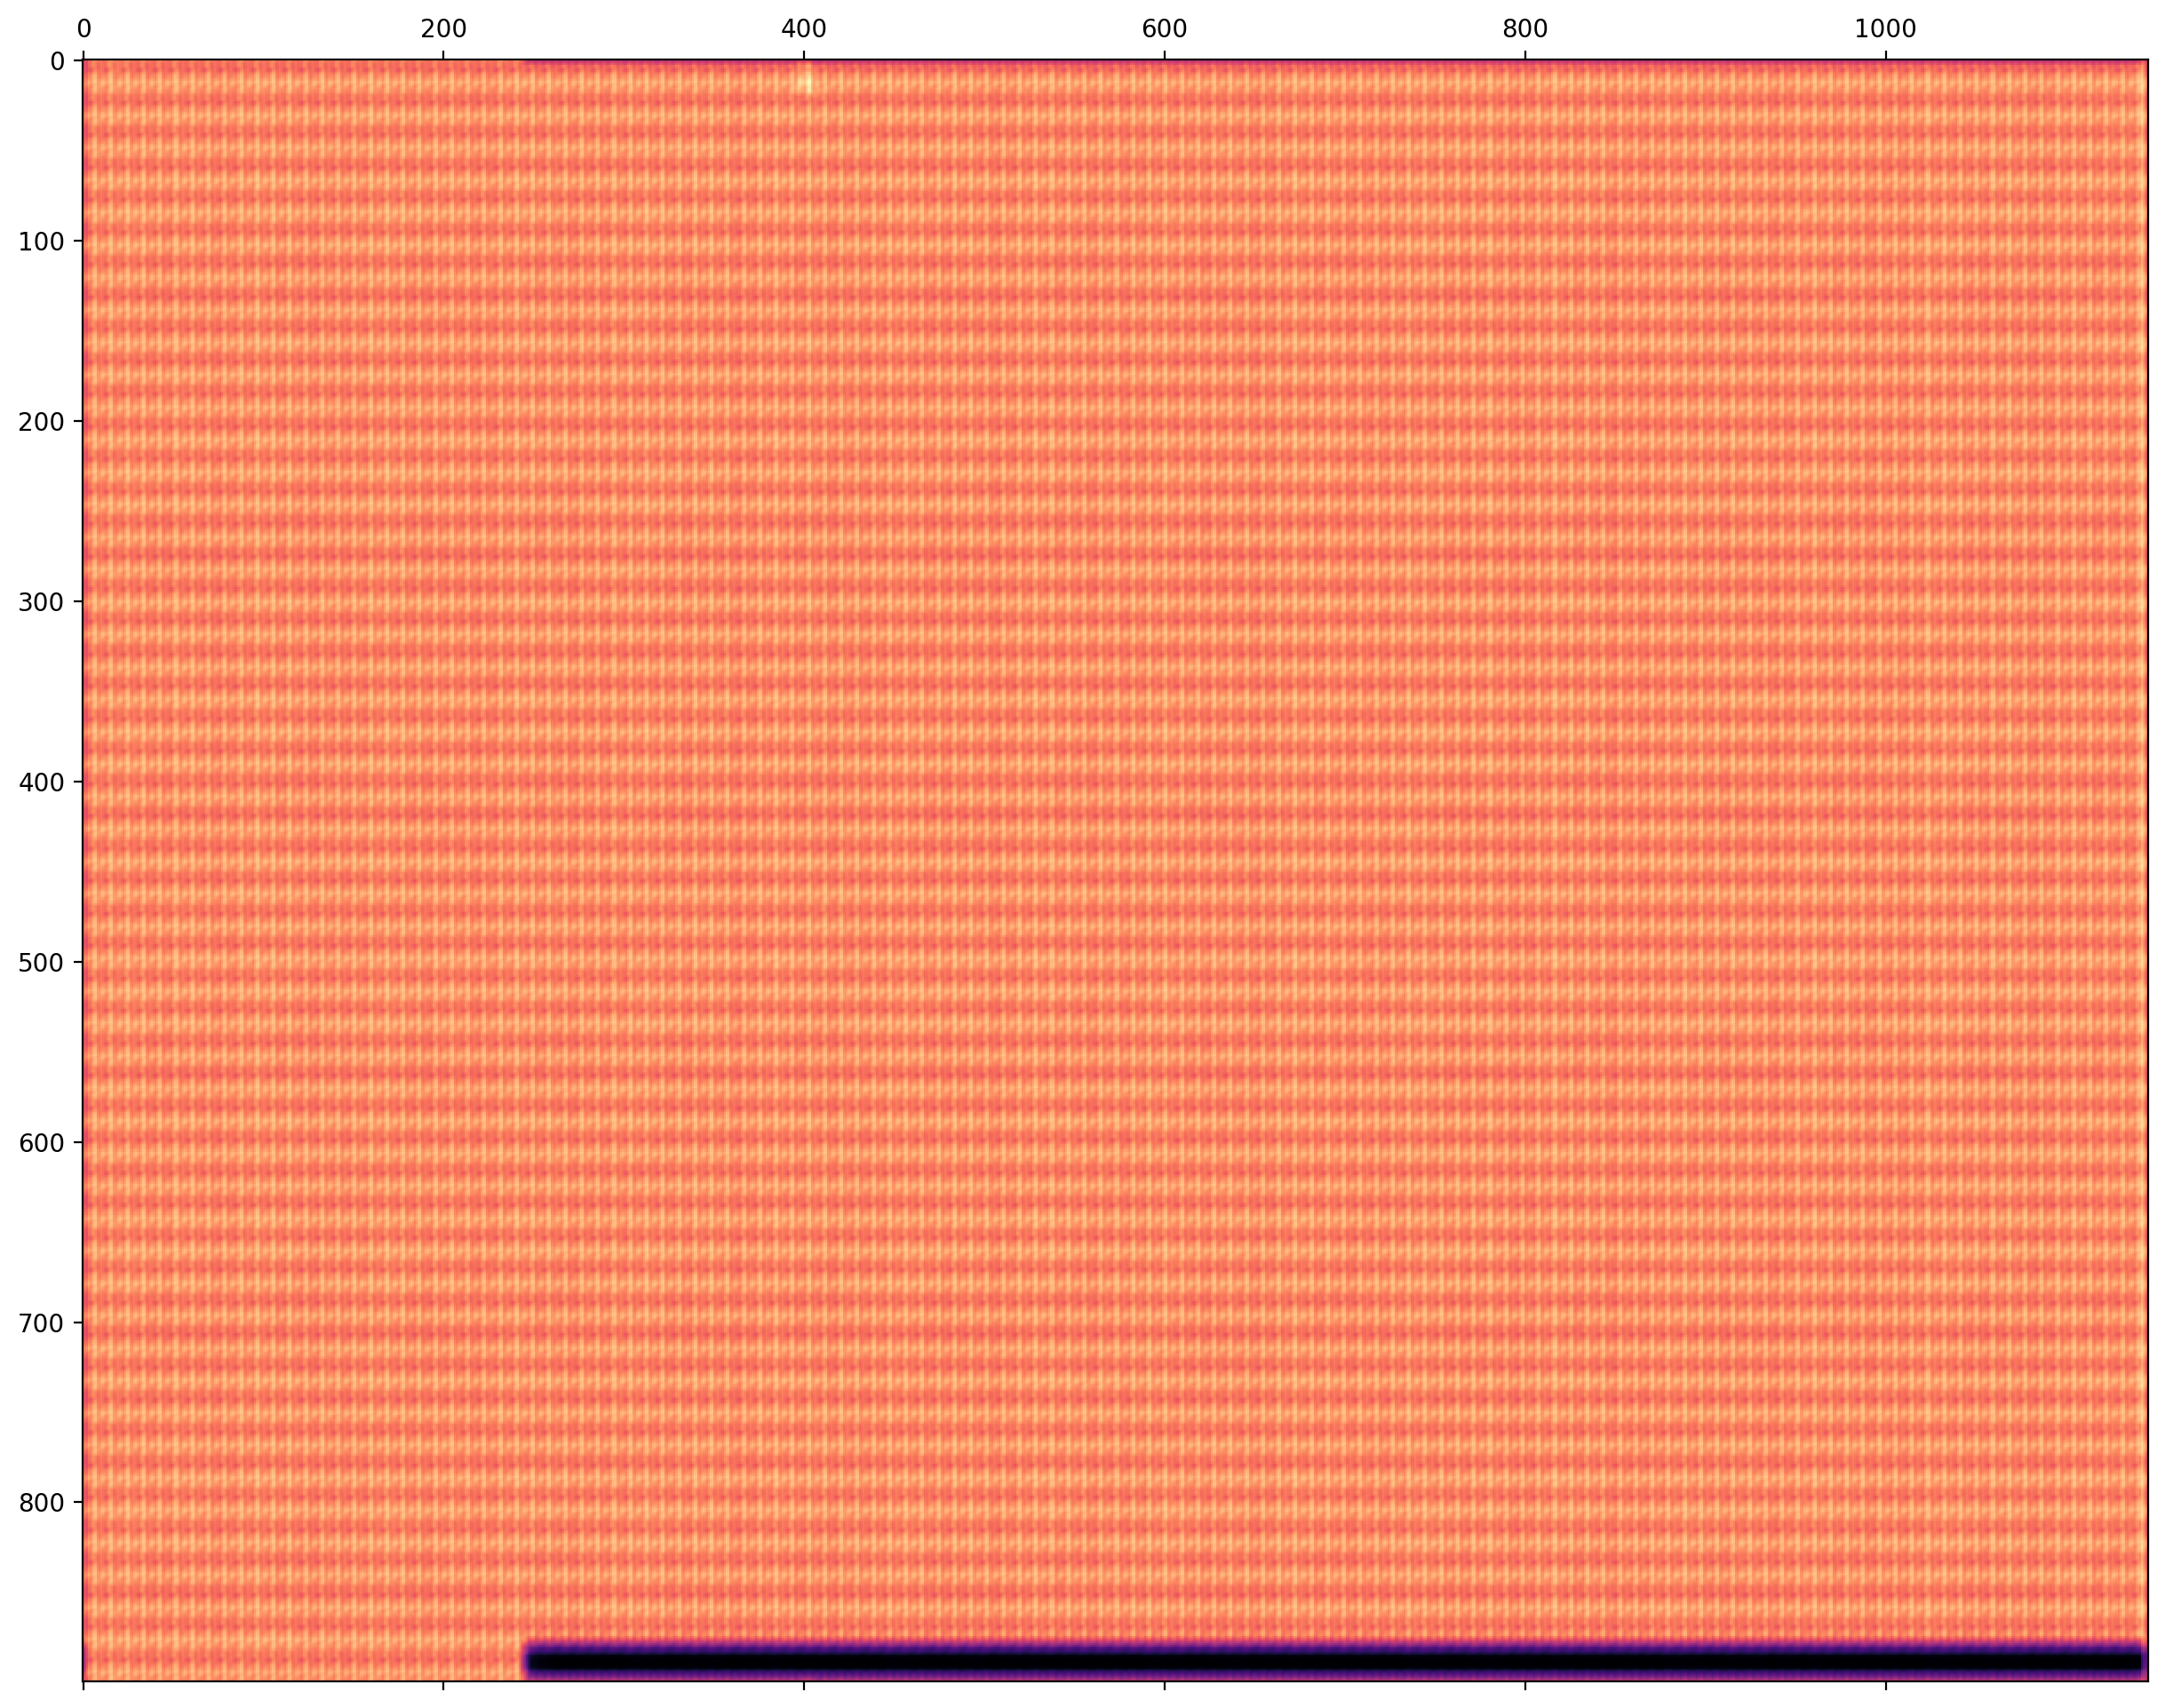

In [28]:
fig, ax = plt.subplots(figsize=(fig_width, fig_width))
ax.matshow(1-xcorr, cmap=plt.magma());

We can easily find the minimum value using https://laurentperrinet.github.io/sciblog/posts/2016-11-17-finding-extremal-values-in-a-nd-array.html

In [29]:
row_min, col_min = np.unravel_index(np.argmin(xcorr.ravel()), xcorr.shape)
row_min, col_min

(np.int64(12), np.int64(402))

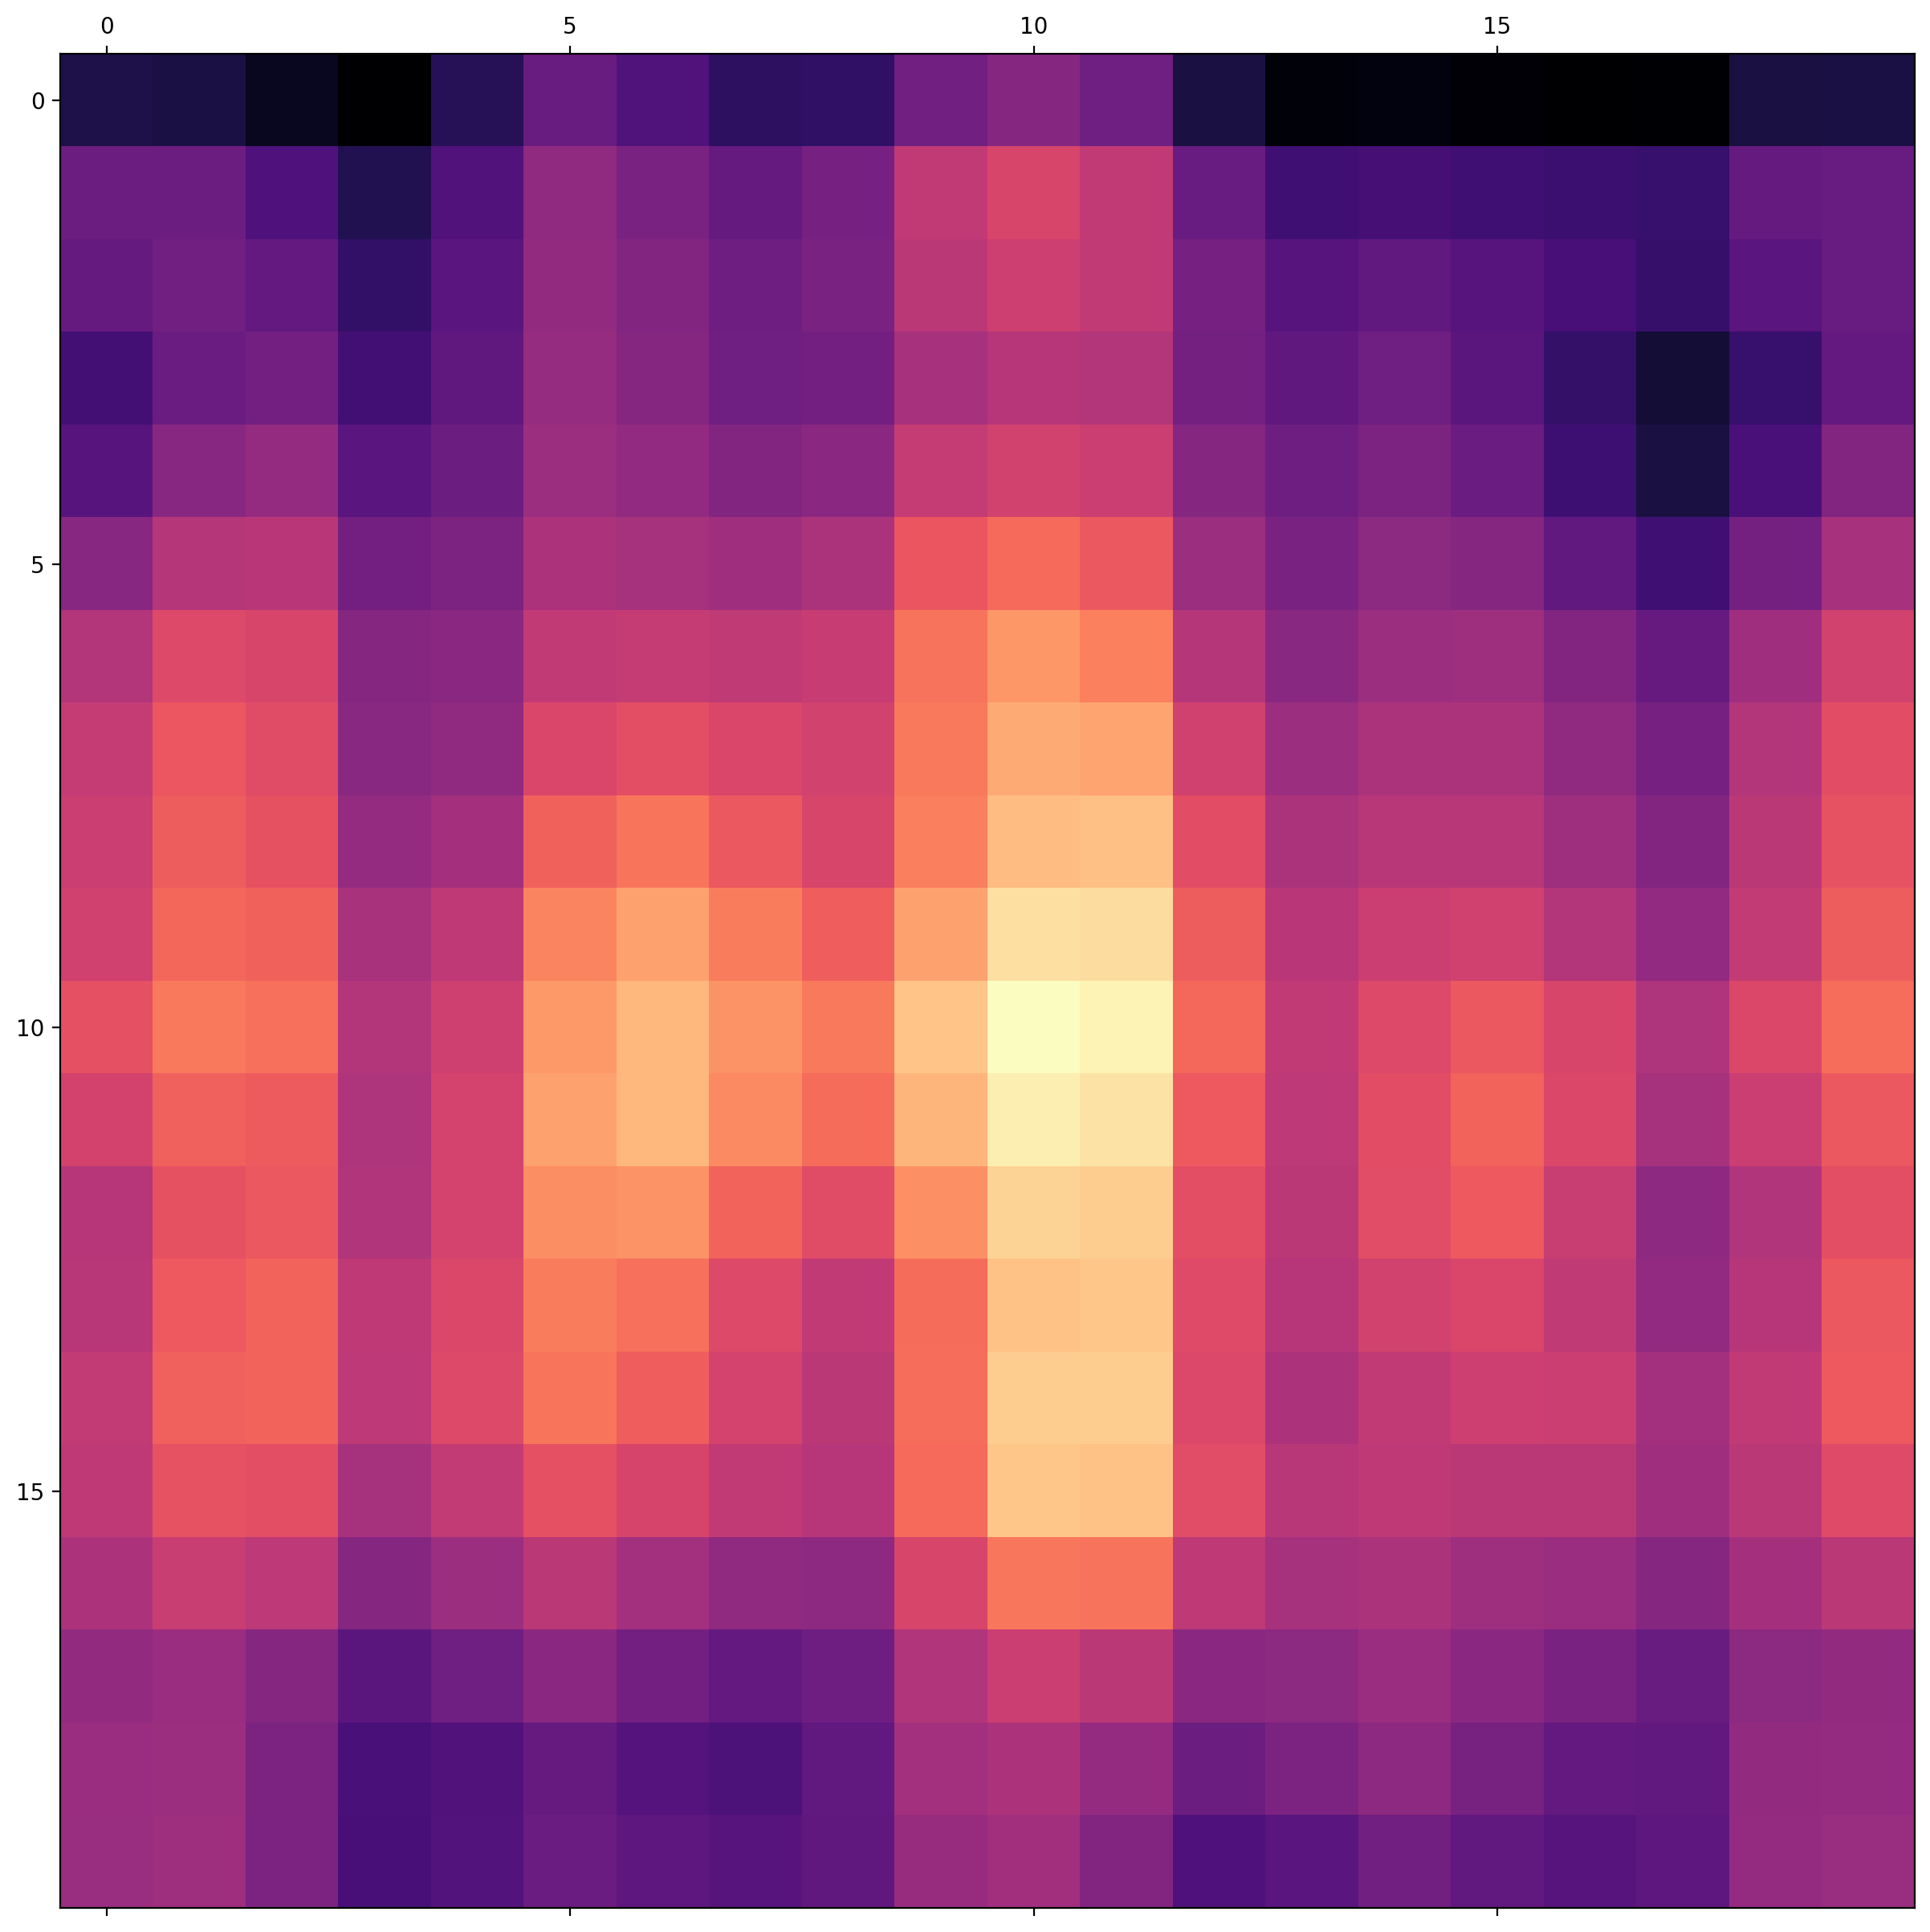

In [30]:
fig, ax = plt.subplots(figsize=(fig_width, fig_width))
ax.matshow(1-xcorr[row_min-10:row_min+10, col_min-10:col_min+10], cmap=plt.magma());

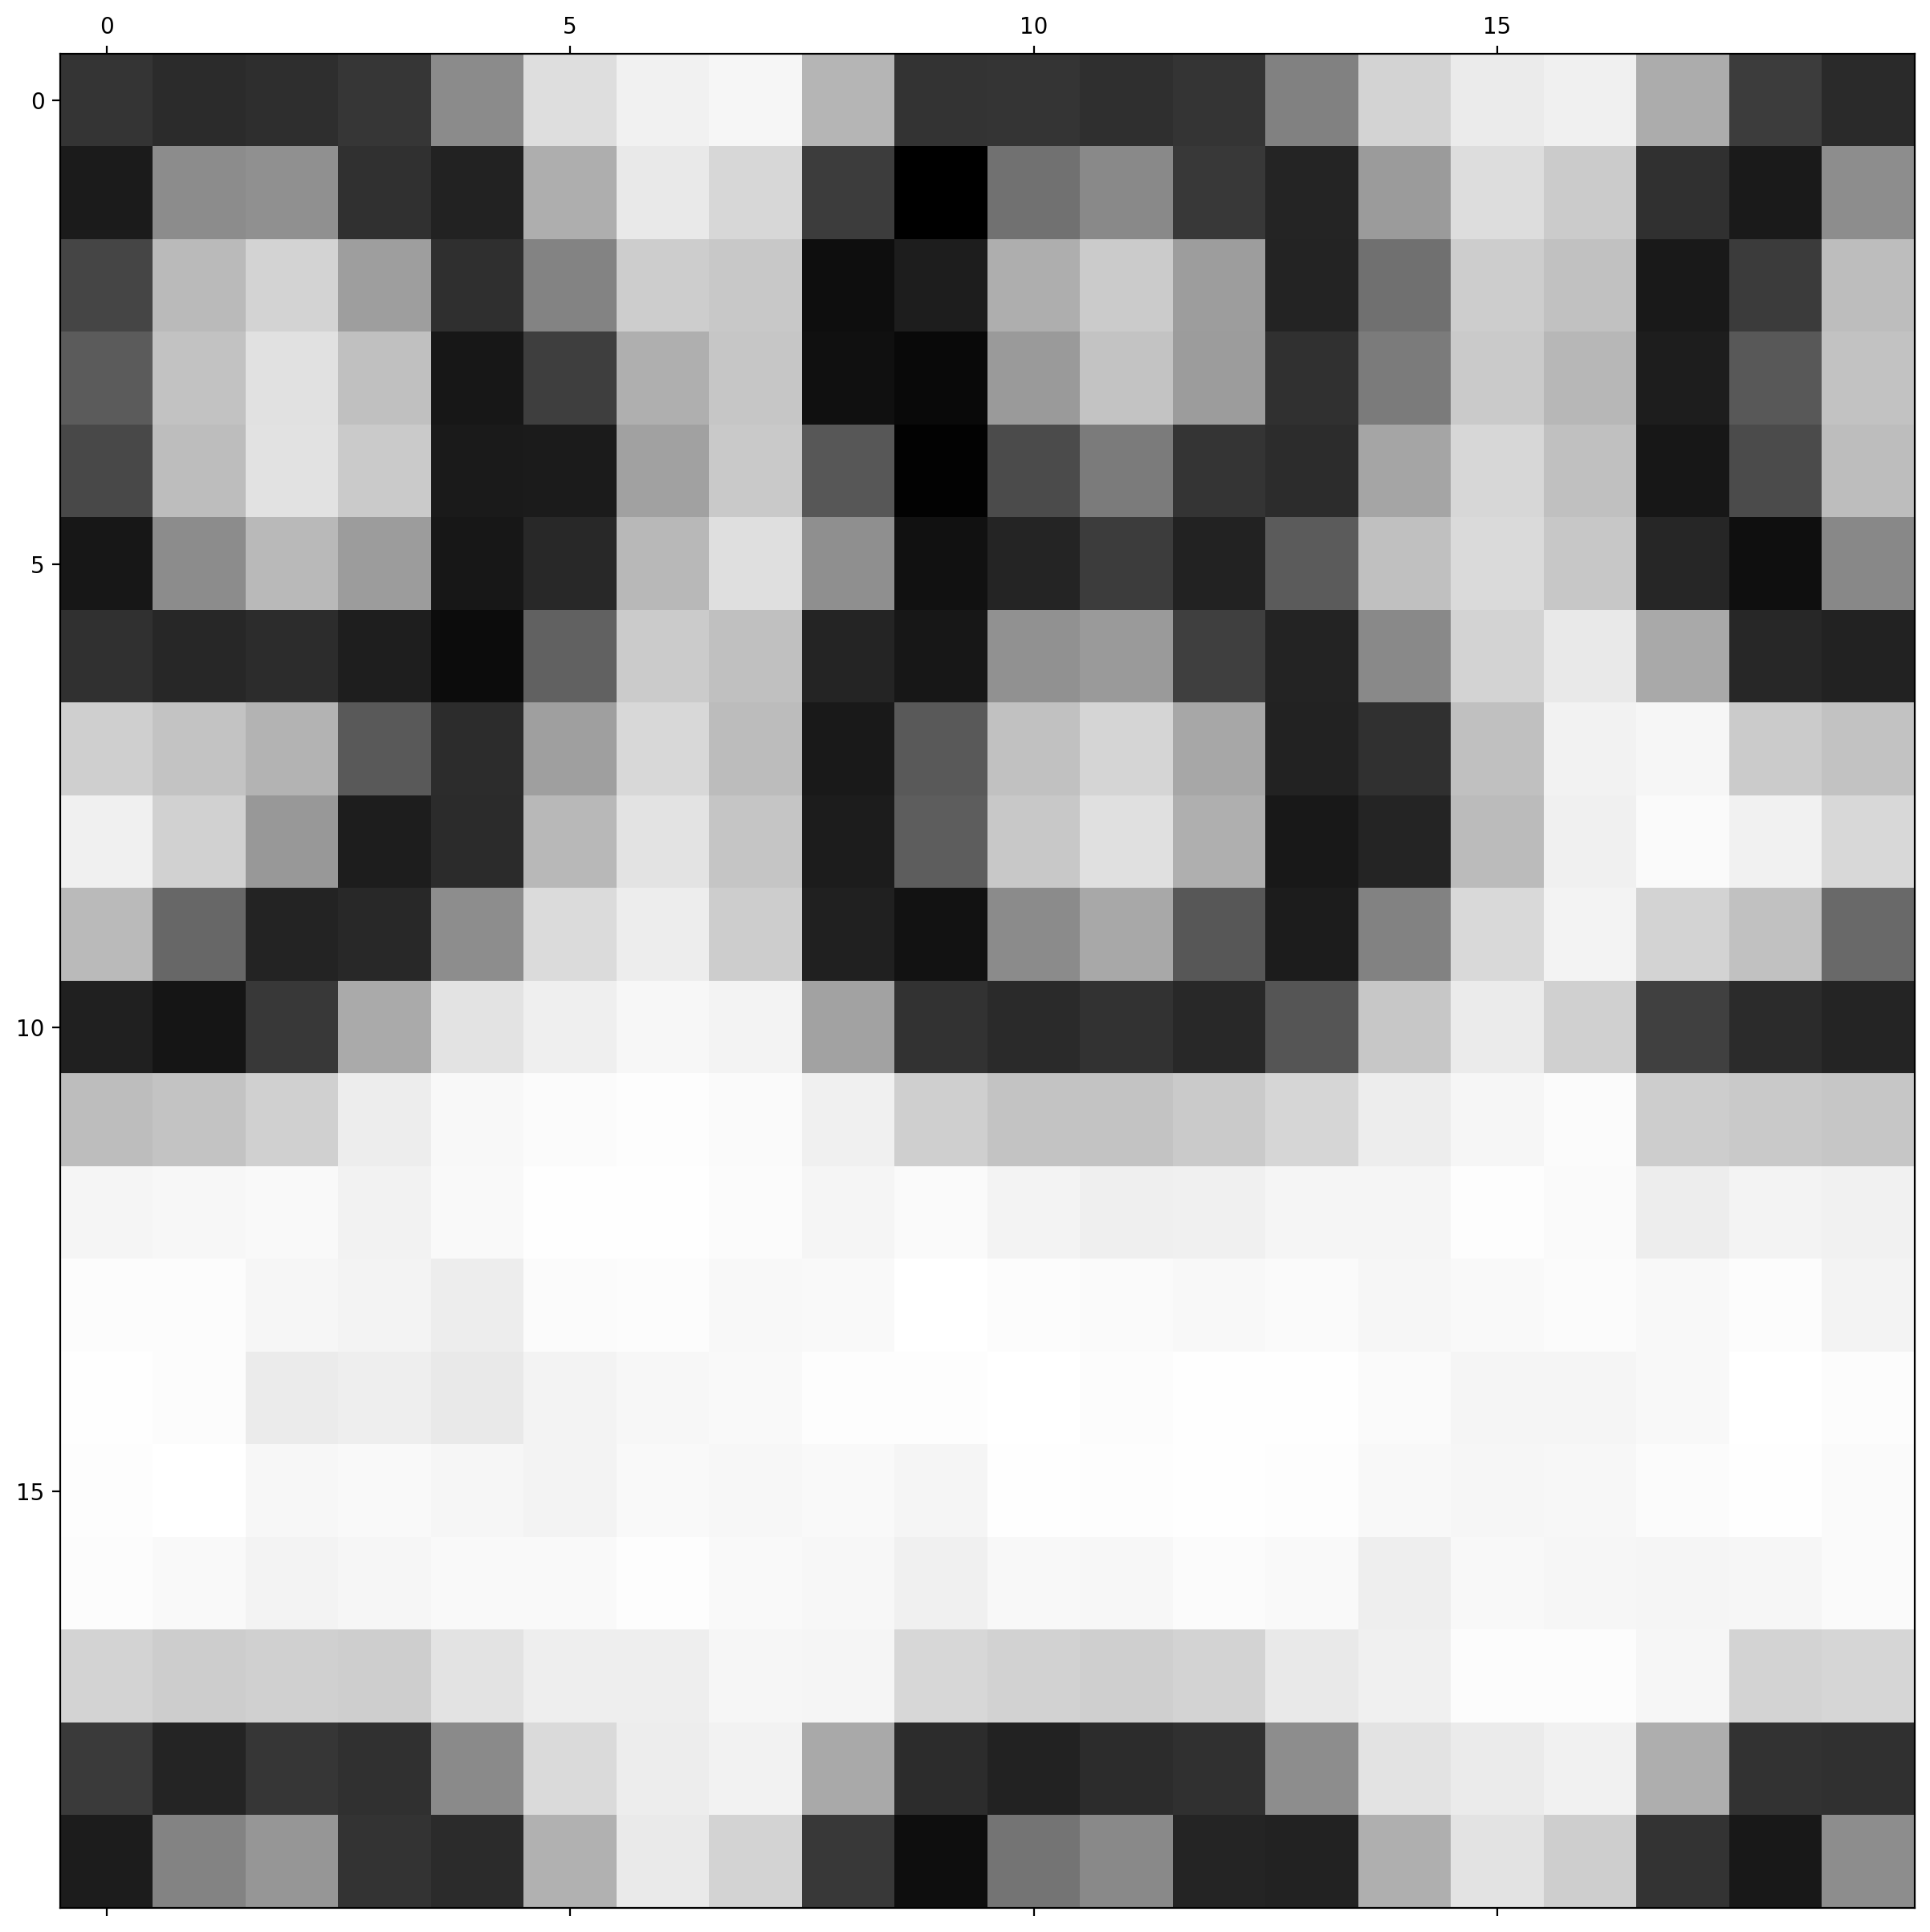

In [31]:
fig, ax = plt.subplots(figsize=(fig_width, fig_width))
ax.matshow(im[row_min-10:row_min+10, col_min-10:col_min+10], cmap=plt.gray());

Here it is ! A solitary *8*...

## some book keeping for the notebook

In [32]:
%load_ext watermark
%watermark -i -h -m -v -p numpy,matplotlib,imageio  -r -g -b

Python implementation: CPython
Python version       : 3.13.12
IPython version      : 9.3.0

numpy     : 2.3.0
matplotlib: 3.10.3
imageio   : 2.37.0

Compiler    : Clang 17.0.0 (clang-1700.6.3.2)
OS          : Darwin
Release     : 24.6.0
Machine     : x86_64
Processor   : i386
CPU cores   : 36
Architecture: 64bit

Hostname: Ahsoka

Git hash: 90dc9f6e9d3e1cb319caa733da02703b074d15b9

Git repo: https://github.com/laurentperrinet/sciblog

Git branch: master

